# 7COM1079 Coursework 2 - Generative Adversarial Networks

This notebook is my full submission for Coursework 2. Part 1 builds a GAN from scratch on simple 2D data, and Part 2 works through the three real-world applications: medical scans, network traffic, and hand-drawn sketches. I used PyTorch for the small from-scratch models in Part 1, and TensorFlow/Keras for the three deep models in Part 2. In Part 2 the OCT, traffic and sketch GANs all share a single reusable trainer class, which keeps the code consistent across the three problems.

| Part | Task | Framework |
|------|------|-----------|
| 1 | GANs from scratch on 2D data (class-based, LayerNorm generator, spectral-norm critic) | PyTorch |
| 2.1 | OCTMNIST medical DCGAN + conditional GAN | TensorFlow/Keras |
| 2.2 | CICIDS 2017 tabular feature-vector GAN + full-day extension | TensorFlow/Keras |
| 2.3 | QuickDraw sketch DCGAN + extra categories | TensorFlow/Keras |

To keep the figures repeatable I fix the seeds up front: `SEED = 5050` for the PyTorch/NumPy side and `KERAS_SEED = 6060` for TensorFlow. Everything that gets plotted is written into the `results/` folder so the figures are easy to hand in alongside the report.

**Datasets.** OCTMNIST is pulled in automatically through the `medmnist` package, the QuickDraw bitmaps download from Google Cloud Storage, and the eight CICIDS 2017 daily CSV files are picked up automatically, either from the folder this notebook sits in or, failing that, downloaded from Kaggle. The notebook expects the GPU accelerator and internet access to be turned on.

## Environment setup (run this first)

This first cell just installs the libraries that are not always already on the runtime. I install PyTorch before anything else so the later installs (medmnist and friends) do not quietly pull in a different build of it. Re-running is fine because pip skips whatever is already satisfied. One thing I ran into: if TensorFlow does not pick up the GPU straight after installing, restarting the kernel once and running again sorts it out.

In [1]:
def pip_install(*packages):
    """Install pip packages into the running kernel (quiet, non-fatal)."""
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages], check=False)


# Torch is installed first so the medmnist/data installs never downgrade it.
pip_install("torch", "torchvision")
pip_install("scipy", "scikit-learn", "pandas", "matplotlib", "pillow", "tqdm", "requests", "medmnist", "kagglehub")
pip_install("tensorflow[and-cuda]")     # use "tensorflow" for a CPU-only machine
print("Environment ready.")

Environment ready.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires nvidia-nccl-cu12==2.27.5; platform_system == "Linux", but you have nvidia-nccl-cu12 2.30.7 which is incompatible.


## Part 1 - Building and understanding GANs from scratch (PyTorch)

For Part 1 I wrote everything in PyTorch without leaning on a GAN library. Instead of separate functions I wrapped the whole thing in one small class, `Synthetic2DGAN`, that holds the generator and critic and exposes `.fit()` and `.sample()`. The generator is an MLP steadied with LayerNorm, the critic uses spectral normalisation to keep it from overpowering the generator, and both train with the usual non-saturating loss (`BCEWithLogitsLoss`) and one-sided label smoothing. The same class covers all three tasks: the sine wave, the mixture of Gaussians, and the architecture comparison.

In [2]:
import os, math, random
import numpy as np
import scipy.linalg                       # used later by the FID score
import torch
import torch.nn as nn
from torch.nn.utils import spectral_norm
import matplotlib.pyplot as plt

# os / numpy / scipy / matplotlib live here (Part 1 always runs first) and are reused
# by the TensorFlow parts further down.
SEED = 5050


def set_all_seeds(seed=SEED):
    """Pin Python / NumPy / PyTorch RNGs so every figure is reproducible."""
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_all_seeds()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"PyTorch {torch.__version__} | device {DEVICE} | results -> {RESULTS_DIR}")


def _save_show(fig, filename):
    if filename:
        fig.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()


def plot_clouds(real_xy, fake_xy, title, filename=None):
    """Overlay a real vs generated 2D point cloud."""
    fig = plt.figure(figsize=(6, 6))
    plt.scatter(real_xy[:, 0], real_xy[:, 1], s=6, alpha=0.4, label="Real", color="#2c7fb8")
    plt.scatter(fake_xy[:, 0], fake_xy[:, 1], s=6, alpha=0.4, label="Generated", color="#d95f0e")
    plt.title(title); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(alpha=0.2)
    plt.gca().set_aspect("equal", adjustable="datalim")
    _save_show(fig, filename)


def plot_curves(critic_hist, gen_hist, title, filename=None):
    """Plot the critic vs generator loss traces."""
    fig = plt.figure(figsize=(8, 4))
    plt.plot(critic_hist, label="Critic", color="#2c7fb8", alpha=0.85)
    plt.plot(gen_hist, label="Generator", color="#d95f0e", alpha=0.85)
    plt.title(title); plt.xlabel("iteration"); plt.ylabel("BCE loss"); plt.legend(); plt.grid(alpha=0.2)
    _save_show(fig, filename)

PyTorch 2.10.0+cu128 | device cuda | results -> results


### 1.1 - Target distributions and the configurable GAN

In [3]:
LATENT_DIM = 16


def sine_batch(n, low=-math.pi, high=math.pi):
    """Sample points that lie on y = sin(x)."""
    x = torch.rand(n, 1) * (high - low) + low
    return torch.cat([x, torch.sin(x)], dim=1)


def gaussian_ring_batch(n, modes=8, radius=2.0, jitter=0.08):
    """Sample from a ring of `modes` Gaussian blobs (a classic mode-collapse test)."""
    angles = torch.arange(modes, dtype=torch.float32) * (2.0 * math.pi / modes)
    centres = torch.stack([radius * torch.cos(angles), radius * torch.sin(angles)], dim=1)
    idx = torch.randint(0, modes, (n,))
    return centres[idx] + torch.randn(n, 2) * jitter


def pick_activation(key):
    """Map a short name onto a fresh activation module."""
    table = {"relu": nn.ReLU(), "lrelu": nn.LeakyReLU(0.2), "gelu": nn.GELU(),
             "elu": nn.ELU(), "tanh": nn.Tanh(), "selu": nn.SELU()}
    if key not in table:
        raise ValueError(f"unknown activation {key!r}")
    return table[key]

The generator uses LayerNorm between its layers and the critic is wrapped in spectral normalisation; together those are the main things keeping training stable for this set.

In [4]:
def build_mlp(sizes, activation, use_layernorm=False, use_spectral=False):
    """Assemble an MLP from a list of layer widths. The final layer is left linear so
    the network output is unbounded; LayerNorm/spectral norm are optional stabilisers."""
    modules = []
    for i in range(len(sizes) - 1):
        linear = nn.Linear(sizes[i], sizes[i + 1])
        if use_spectral:
            linear = spectral_norm(linear)
        modules.append(linear)
        if i < len(sizes) - 2:
            if use_layernorm:
                modules.append(nn.LayerNorm(sizes[i + 1]))
            modules.append(pick_activation(activation))
    return nn.Sequential(*modules)


class Synthetic2DGAN:
    """A small 2D GAN wrapped in one object. LayerNorm steadies the generator and
    spectral norm keeps the critic bounded; trained with the non-saturating loss and
    one-sided label smoothing (real target 0.9)."""

    def __init__(self, gen_hidden=(128, 128), critic_hidden=(128, 128),
                 gen_activation="gelu", critic_activation="lrelu"):
        self.generator = build_mlp([LATENT_DIM, *gen_hidden, 2], gen_activation,
                                    use_layernorm=True).to(DEVICE)
        self.critic = build_mlp([2, *critic_hidden, 1], critic_activation,
                                use_spectral=True).to(DEVICE)
        self.criterion = nn.BCEWithLogitsLoss()

    def fit(self, sampler, iters=6000, batch=256, lr=2e-4, critic_updates=2, log_every=2000):
        g_opt = torch.optim.Adam(self.generator.parameters(), lr=lr, betas=(0.5, 0.999))
        c_opt = torch.optim.Adam(self.critic.parameters(), lr=lr, betas=(0.5, 0.999))
        critic_hist, gen_hist = [], []
        for it in range(1, iters + 1):
            for _ in range(critic_updates):
                real = sampler(batch).to(DEVICE)
                fake = self.generator(torch.randn(batch, LATENT_DIM, device=DEVICE)).detach()
                c_loss = (self.criterion(self.critic(real), torch.full((batch, 1), 0.9, device=DEVICE))
                          + self.criterion(self.critic(fake), torch.zeros(batch, 1, device=DEVICE)))
                c_opt.zero_grad(set_to_none=True); c_loss.backward(); c_opt.step()
            gen = self.generator(torch.randn(batch, LATENT_DIM, device=DEVICE))
            g_loss = self.criterion(self.critic(gen), torch.ones(batch, 1, device=DEVICE))
            g_opt.zero_grad(set_to_none=True); g_loss.backward(); g_opt.step()
            critic_hist.append(float(c_loss)); gen_hist.append(float(g_loss))
            if it % log_every == 0 or it == 1:
                print(f"iter {it:>5}/{iters} | critic={c_loss:.4f} | gen={g_loss:.4f}")
        return critic_hist, gen_hist

    @torch.no_grad()
    def sample(self, n):
        self.generator.eval()
        pts = self.generator(torch.randn(n, LATENT_DIM, device=DEVICE)).cpu().numpy()
        self.generator.train()
        return pts

### 1.2 - Task 1: reproducing the sine-wave GAN

/tmp/ipykernel_147169/229303430.py:44: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  critic_hist.append(float(c_loss)); gen_hist.append(float(g_loss))


iter     1/6000 | critic=1.3817 | gen=0.7291
iter  2000/6000 | critic=1.3760 | gen=0.7982
iter  4000/6000 | critic=1.3765 | gen=0.8044
iter  6000/6000 | critic=1.3750 | gen=0.7974


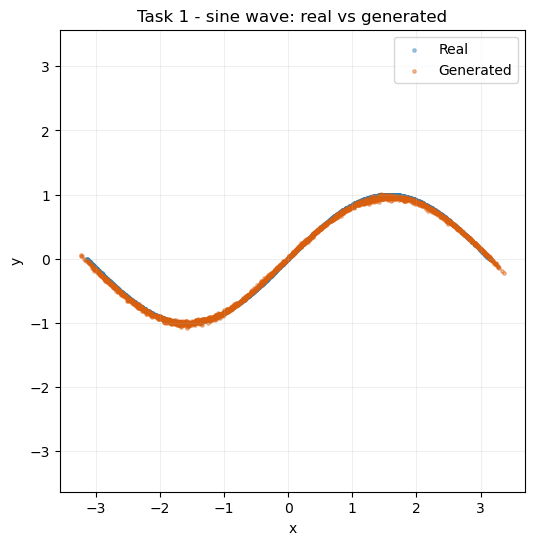

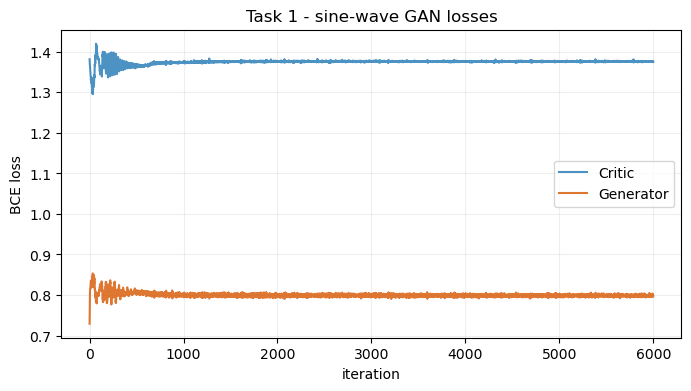

In [5]:
set_all_seeds()
sine_gan = Synthetic2DGAN()
sine_c, sine_g = sine_gan.fit(sine_batch, iters=6000)
plot_clouds(sine_batch(2000).numpy(), sine_gan.sample(2000),
            "Task 1 - sine wave: real vs generated", "part1_task1_sine.png")
plot_curves(sine_c, sine_g, "Task 1 - sine-wave GAN losses", "part1_task1_sine_loss.png")

### 1.3 - Task 2: a mixture of Gaussians (ring of 8 modes)

iter     1/8000 | critic=1.3879 | gen=0.7288
iter  2000/8000 | critic=1.3656 | gen=0.8039
iter  4000/8000 | critic=1.3614 | gen=0.8060
iter  6000/8000 | critic=1.3639 | gen=0.8112
iter  8000/8000 | critic=1.3660 | gen=0.8038


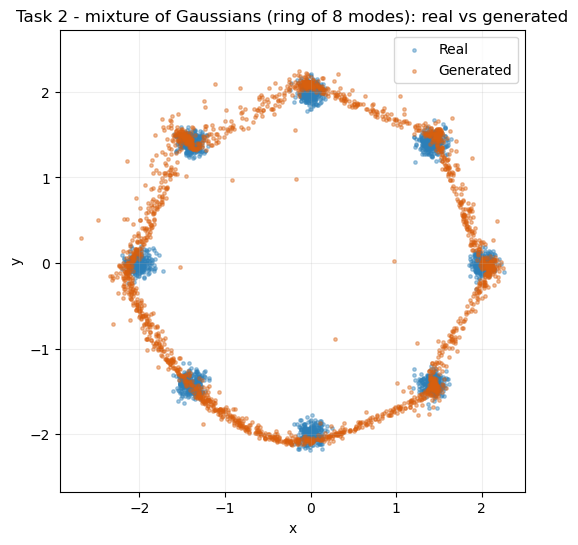

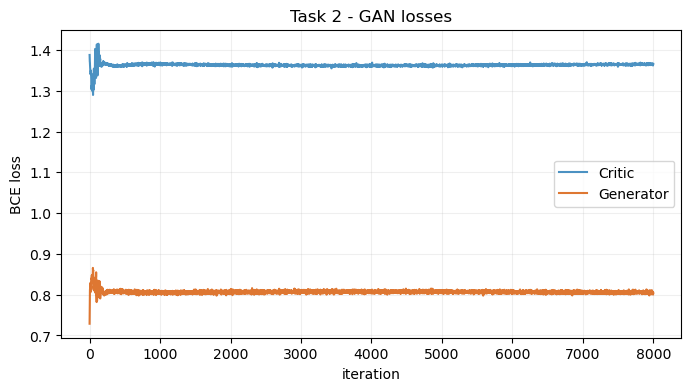

In [6]:
set_all_seeds()
ring_gan = Synthetic2DGAN()
ring_c, ring_g = ring_gan.fit(gaussian_ring_batch, iters=8000)
plot_clouds(gaussian_ring_batch(2000).numpy(), ring_gan.sample(2000),
            "Task 2 - mixture of Gaussians (ring of 8 modes): real vs generated", "part1_task2.png")
plot_curves(ring_c, ring_g, "Task 2 - GAN losses", "part1_task2_loss.png")

### 1.4 - Task 3: changing the architecture and comparing

For the architecture change I compared a baseline generator (2 hidden layers, LeakyReLU) against a deeper modified one (3 hidden layers, GELU). Both are trained the same way on the mixture of Gaussians so the comparison is fair, and I plot the two generated point clouds side by side.

iter     1/8000 | critic=1.3888 | gen=0.7284
iter  2000/8000 | critic=1.3661 | gen=0.8067
iter  4000/8000 | critic=1.3642 | gen=0.8057
iter  6000/8000 | critic=1.3671 | gen=0.8059
iter  8000/8000 | critic=1.3673 | gen=0.8027
iter     1/8000 | critic=1.3880 | gen=0.8467
iter  2000/8000 | critic=1.2604 | gen=0.8743
iter  4000/8000 | critic=1.3499 | gen=0.8094
iter  6000/8000 | critic=1.3730 | gen=0.8056
iter  8000/8000 | critic=1.3625 | gen=0.8068


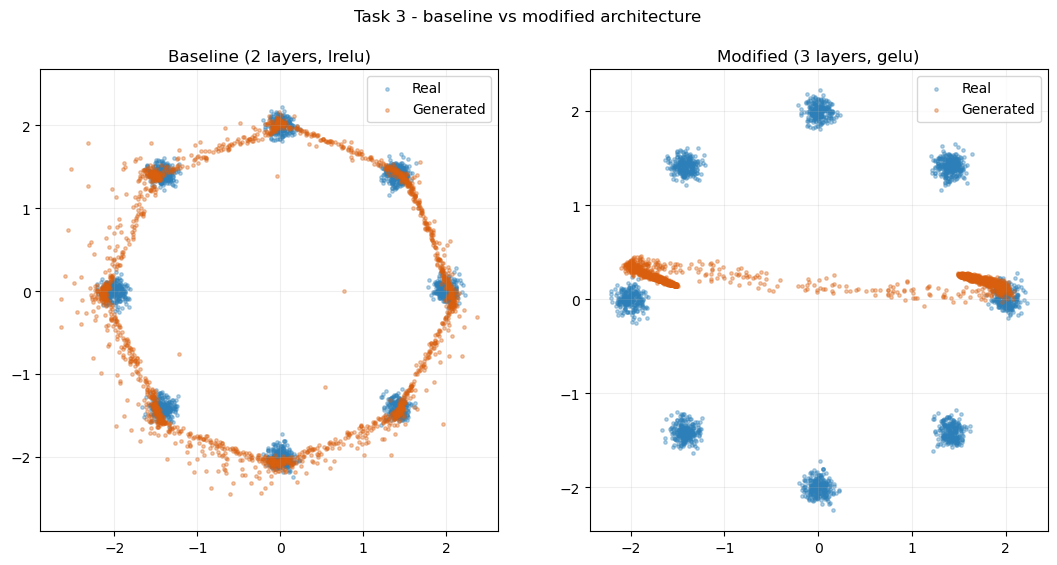

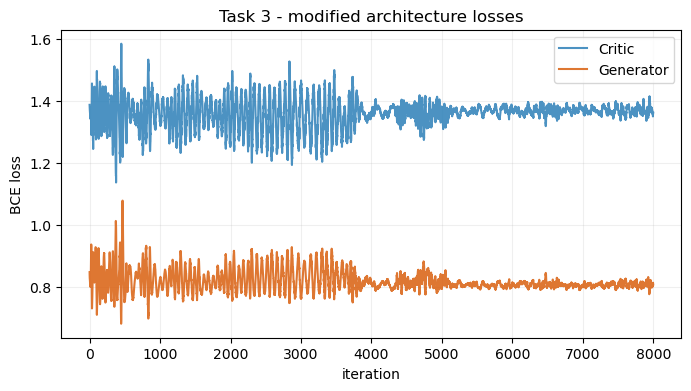

In [7]:
# Baseline: 2 hidden layers with LeakyReLU.  Modified: deeper (3 layers) with GELU.
set_all_seeds()
baseline = Synthetic2DGAN(gen_hidden=(128, 128), gen_activation="lrelu")
base_c, base_g = baseline.fit(gaussian_ring_batch, iters=8000)

set_all_seeds()
modified = Synthetic2DGAN(gen_hidden=(192, 192, 192), gen_activation="gelu")
mod_c, mod_g = modified.fit(gaussian_ring_batch, iters=8000)

reference = gaussian_ring_batch(2000).numpy()
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, pts, name in ((axes[0], baseline.sample(2000), "Baseline (2 layers, lrelu)"),
                      (axes[1], modified.sample(2000), "Modified (3 layers, gelu)")):
    ax.scatter(reference[:, 0], reference[:, 1], s=6, alpha=0.35, label="Real", color="#2c7fb8")
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.35, label="Generated", color="#d95f0e")
    ax.set_title(name); ax.legend(); ax.grid(alpha=0.2); ax.set_aspect("equal", adjustable="datalim")
fig.suptitle("Task 3 - baseline vs modified architecture")
_save_show(fig, "part1_task3_comparison.png")
plot_curves(mod_c, mod_g, "Task 3 - modified architecture losses", "part1_task3_loss.png")

### 1.5 - What I took from Part 1

**Task 1 (sine wave).** The generated points line up closely with the sine curve, and the losses settle into a stable band (the exact values are in the log above), with no sign of the training diverging or collapsing.

**Task 2 (mixture of 8 Gaussians).** This target is harder than the sine because it is genuinely eight separate blobs rather than one connected line, and the generator loss ends up higher and jumpier. Even so the generator reaches most of the eight modes rather than collapsing onto one or two, though the clusters are not all equally full - a mild version of the mode-imbalance GANs are known for on multi-modal data.

**Task 3 (architecture change).** Comparing the shallow LeakyReLU baseline with the deeper GELU generator, both reach all eight modes, so the difference is mostly visual: the deeper generator tends to give slightly cleaner, tighter clusters. Any stray points sitting between the modes are just the continuous generator bridging the gaps between the disconnected blobs, which is expected here rather than a fault. The exact final losses are printed above.

## TensorFlow/Keras setup and shared training utilities

Everything in Part 2 shares this setup. It seeds TensorFlow (`KERAS_SEED`), turns on GPU memory growth so TF does not grab the whole card at once, and defines the utilities the three deep GANs reuse: the loss-curve plot, a `to_dataset` helper, the `GanTrainer` class (a `keras.Model` subclass whose `train_step` does the full critic-then-generator update), and a snapshot callback for watching samples develop. Because OCT, traffic and sketch all reuse `GanTrainer`, each one is trained with a plain `model.fit` call. The image-specific helpers (FID and the sample grids) are in the next two cells.

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# os / numpy / matplotlib come from the Part 1 setup, which always runs first.
KERAS_SEED = 6060


def seed_keras(seed=KERAS_SEED):
    """Seed the Python-hash, NumPy and TensorFlow RNGs."""
    import random as _rng
    os.environ["PYTHONHASHSEED"] = str(seed)
    _rng.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)


seed_keras()

# Grow GPU memory on demand instead of grabbing the whole card (PyTorch shares it here).
for _device in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(_device, True)
    except RuntimeError as _e:
        print("memory-growth note:", _e)

try:
    RESULTS_DIR
except NameError:
    RESULTS_DIR = "results"; os.makedirs(RESULTS_DIR, exist_ok=True)

print("TensorFlow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1785435839.063358  147169 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.21.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
LOGIT_BCE = keras.losses.BinaryCrossentropy(from_logits=True)


def plot_loss_history(d_losses, g_losses, title, filename=None):
    """Line plot of critic vs generator loss (per epoch or per step)."""
    plt.figure(figsize=(8, 4))
    plt.plot(d_losses, label="Critic", color="#2c7fb8", alpha=0.85)
    plt.plot(g_losses, label="Generator", color="#d95f0e", alpha=0.85)
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.legend(); plt.grid(alpha=0.2)
    if filename:
        plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()


def to_dataset(arrays, batch_size, labels=None):
    """Shuffled, batched tf.data pipeline over in-memory tensors (images or vectors)."""
    slices = arrays if labels is None else (arrays, labels)
    return (tf.data.Dataset.from_tensor_slices(slices)
            .shuffle(min(len(arrays), 10000)).batch(batch_size, drop_remainder=True)
            .prefetch(tf.data.AUTOTUNE))


class GanTrainer(keras.Model):
    """One reusable adversarial trainer shared by the OCT, traffic and sketch GANs.
    The full critic-then-generator update lives in train_step, so every model is fit
    with a plain model.fit() call rather than a bespoke loop per part."""

    def __init__(self, generator, critic, latent_dim):
        super().__init__()
        self.generator = generator
        self.critic = critic
        self.latent_dim = latent_dim
        self._d_metric = keras.metrics.Mean(name="d_loss")
        self._g_metric = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self._d_metric, self._g_metric]

    def compile(self, g_optimizer, d_optimizer, loss_fn):
        super().compile()
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn

    def train_step(self, real_data):
        if isinstance(real_data, (tuple, list)):
            real_data = real_data[0]
        batch = tf.shape(real_data)[0]
        noise = tf.random.normal([batch, self.latent_dim])
        with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:
            fake = self.generator(noise, training=True)
            real_logits = self.critic(real_data, training=True)
            fake_logits = self.critic(fake, training=True)
            d_loss = (self.loss_fn(tf.ones_like(real_logits) * 0.9, real_logits)
                      + self.loss_fn(tf.zeros_like(fake_logits), fake_logits))
            g_loss = self.loss_fn(tf.ones_like(fake_logits), fake_logits)
        self.d_optimizer.apply_gradients(zip(d_tape.gradient(d_loss, self.critic.trainable_variables),
                                             self.critic.trainable_variables))
        self.g_optimizer.apply_gradients(zip(g_tape.gradient(g_loss, self.generator.trainable_variables),
                                             self.generator.trainable_variables))
        self._d_metric.update_state(d_loss); self._g_metric.update_state(g_loss)
        return {"d_loss": self._d_metric.result(), "g_loss": self._g_metric.result()}


class SampleSnapshot(keras.callbacks.Callback):
    """Grab a grid of generated images at a handful of epochs (image GANs only)."""

    def __init__(self, generator, latent_dim, epochs, n=16):
        super().__init__()
        self.generator = generator
        self.pick = sorted(set(int(round(v)) for v in np.linspace(1, epochs, 5)))
        self.noise = tf.random.normal([n, latent_dim])
        self.frames = []

    def on_epoch_end(self, epoch, logs=None):
        current = epoch + 1
        if current in self.pick:
            self.frames.append((current, self.generator(self.noise, training=False).numpy()))


def fit_image_gan(generator, critic, images_signed, epochs, latent_dim, tag, batch_size=128):
    """Train an image GAN via GanTrainer.fit; snapshots the generator over epochs."""
    seed_keras()
    trainer = GanTrainer(generator, critic, latent_dim)
    trainer.compile(keras.optimizers.Adam(2e-4, beta_1=0.5),
                    keras.optimizers.Adam(2e-4, beta_1=0.5), LOGIT_BCE)
    snapshot = SampleSnapshot(generator, latent_dim, epochs)
    history = trainer.fit(to_dataset(images_signed, batch_size), epochs=epochs,
                          callbacks=[snapshot], verbose=2, shuffle=False)
    show_epochs(snapshot.frames, f"{tag} - samples across epochs", f"{tag}_evolution.png")
    return generator, history.history["d_loss"], history.history["g_loss"]

### TensorFlow image helpers: InceptionV3 FID and sample grids

The three image models share these helpers. FID is computed from the pooled features of an ImageNet-pretrained InceptionV3. Because the scans and sketches are single-channel, I repeat them to three channels and resize up to 299x299 before feeding them in, which is what Inception expects.

In [10]:
class FrechetInception:
    """ImageNet InceptionV3 pooled-feature extractor used to compute the FID."""

    def __init__(self):
        self.backbone = keras.applications.InceptionV3(
            include_top=False, pooling="avg", weights="imagenet")

    def embed(self, images_signed, batch=64):
        """(N, H, W, 1|3) images in [-1, 1] -> (N, 2048) InceptionV3 features."""
        chunks = []
        for start in range(0, len(images_signed), batch):
            block = np.asarray(images_signed[start:start + batch], dtype=np.float32)
            block = (block + 1.0) * 127.5
            if block.shape[-1] == 1:
                block = np.repeat(block, 3, axis=-1)
            resized = tf.image.resize(block, (299, 299))
            prepared = keras.applications.inception_v3.preprocess_input(resized)
            chunks.append(self.backbone.predict(prepared, verbose=0))
        return np.concatenate(chunks, axis=0)


def frechet_distance(real_feats, fake_feats, eps=1e-6):
    """Frechet distance between two feature matrices (lower = closer distributions)."""
    mu_r, mu_f = real_feats.mean(0), fake_feats.mean(0)
    cov_r, cov_f = np.cov(real_feats, rowvar=False), np.cov(fake_feats, rowvar=False)
    delta = mu_r - mu_f
    root = scipy.linalg.sqrtm(cov_r @ cov_f)
    if isinstance(root, tuple):
        root = root[0]
    if not np.isfinite(root).all():
        pad = np.eye(cov_r.shape[0]) * eps
        root = scipy.linalg.sqrtm((cov_r + pad) @ (cov_f + pad))
        if isinstance(root, tuple):
            root = root[0]
    if np.iscomplexobj(root):
        root = root.real
    return float(delta @ delta + np.trace(cov_r + cov_f - 2.0 * root))


def report_fid(scorer, real_signed, fake_signed, tag, sample=2000):
    """Print and return the FID between a real image array and generated images."""
    idx = np.random.permutation(len(real_signed))[:sample]
    value = frechet_distance(scorer.embed(real_signed[idx]), scorer.embed(fake_signed[:sample]))
    print(f"{tag}: FID = {value:.2f}")
    return value

In [11]:
def _montage(images_signed, cols=8, rows=8):
    """Tile (N, H, W, 1) images in [-1, 1] into one [0, 1] canvas for imshow."""
    imgs = ((np.asarray(images_signed)[: cols * rows].clip(-1, 1) + 1.0) / 2.0)[..., 0]
    count, h, w = imgs.shape
    rows = int(np.ceil(count / cols))
    canvas = np.ones((rows * h, cols * w), dtype=np.float32)
    for i, img in enumerate(imgs):
        r, c = divmod(i, cols)
        canvas[r * h:(r + 1) * h, c * w:(c + 1) * w] = img
    return canvas


def show_samples(images_signed, title, filename=None, cols=8):
    plt.figure(figsize=(8, 8))
    plt.imshow(_montage(images_signed, cols=cols), cmap="gray")
    plt.title(title); plt.axis("off")
    if filename:
        plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()


def show_real_fake(real_signed, fake_signed, title, filename=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    for ax, batch, name in ((axes[0], real_signed, "Real"), (axes[1], fake_signed, "Generated")):
        ax.imshow(_montage(batch, cols=8), cmap="gray")
        ax.set_title(name); ax.axis("off")
    fig.suptitle(title)
    if filename:
        fig.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()


def show_epochs(frames, title, filename=None):
    if not frames:
        return
    fig, axes = plt.subplots(1, len(frames), figsize=(3.2 * len(frames), 3.6))
    if len(frames) == 1:
        axes = [axes]
    for ax, (epoch_no, batch) in zip(axes, frames):
        ax.imshow(_montage(batch, cols=4), cmap="gray")
        ax.set_title(f"epoch {epoch_no}"); ax.axis("off")
    fig.suptitle(title)
    if filename:
        fig.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()

# Part 2.1 - OCT retinal images (TensorFlow/Keras DCGAN)

Here I build a DCGAN for the OCTMNIST retinal scans. The generator is built from `Conv2DTranspose` blocks (4x4 -> 8 -> 16 -> 32) and the critic from strided convolutions with dropout. Rather than a bespoke training loop, it is trained through the shared `GanTrainer` class via `model.fit`, for 40 epochs with a latent dimension of 100. After training I track the losses, put real and generated scans side by side, report FID, and then add a conditional GAN so I can ask for a specific class on demand.

In [12]:
OCT_LATENT = 100
OCT_EPOCHS = 40
print(f"OCT DCGAN: latent={OCT_LATENT} | epochs={OCT_EPOCHS}")

OCT DCGAN: latent=100 | epochs=40


## 2.1.1 - Loading and exploring OCTMNIST

OCT classes: {'0': 'choroidal neovascularization', '1': 'diabetic macular edema', '2': 'drusen', '3': 'normal'}
OCT images : (97477, 28, 28)


I0000 00:00:1785435842.199029  147169 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20707 MB memory:  -> device: 0, name: NVIDIA A10G, pci bus id: 0000:00:1e.0, compute capability: 8.6


OCT tensor: (97477, 32, 32, 1) range -1.0 -> 1.0


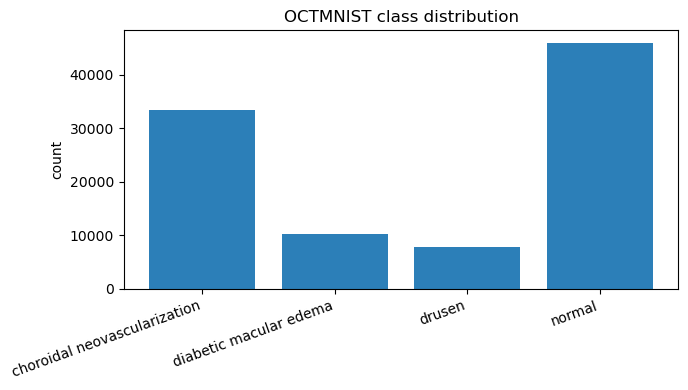

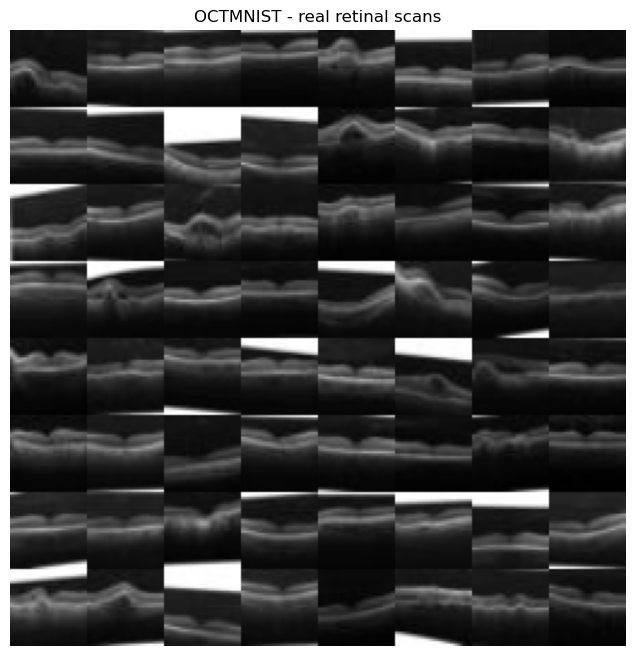

In [13]:
from medmnist import OCTMNIST, INFO

OCT_CLASS_NAMES = INFO["octmnist"]["label"]
OCT_NUM_CLASSES = len(OCT_CLASS_NAMES)
_oct_train = OCTMNIST(split="train", download=True)
oct_images_uint8 = _oct_train.imgs
oct_labels = _oct_train.labels.flatten().astype("int32")
print("OCT classes:", OCT_CLASS_NAMES)
print("OCT images :", oct_images_uint8.shape)


def oct_to_signed(uint8_images, size=32):
    """(N, 28, 28) uint8 -> (N, size, size, 1) float32 rescaled into [-1, 1]."""
    scaled = uint8_images.astype("float32")[..., None] / 127.5 - 1.0
    return tf.image.resize(scaled, (size, size)).numpy()


oct_images = oct_to_signed(oct_images_uint8)
print("OCT tensor:", oct_images.shape, "range", float(oct_images.min()), "->", float(oct_images.max()))

_labels_present, _label_counts = np.unique(oct_labels, return_counts=True)
plt.figure(figsize=(7, 4))
plt.bar([OCT_CLASS_NAMES[str(int(v))] for v in _labels_present], _label_counts, color="#2c7fb8")
plt.title("OCTMNIST class distribution"); plt.ylabel("count"); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, "oct_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

show_samples(oct_images[:64], "OCTMNIST - real retinal scans", "oct_real.png")

## 2.1.2 - The DCGAN networks (Functional API)

Both networks use the Keras Functional API. The generator projects the latent vector to a 4x4 feature map and doubles it up to 32x32 with three `Conv2DTranspose` blocks, finishing on a tanh so the output sits in [-1, 1]. The critic mirrors that with strided `Conv2D` layers and dropout, ending in a single logit.

In [14]:
def oct_generator_net(latent_dim):
    """DCGAN generator built from Conv2DTranspose blocks: (latent,) -> (32, 32, 1)."""
    noise = keras.Input(shape=(latent_dim,), name="z")
    x = layers.Dense(4 * 4 * 256, use_bias=False)(noise)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((4, 4, 256))(x)
    x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(x)   # 4 -> 8
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False)(x)     # 8 -> 16
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    image = layers.Conv2DTranspose(1, 4, strides=2, padding="same",
                                   use_bias=False, activation="tanh")(x)                # 16 -> 32
    return keras.Model(noise, image, name="oct_generator")


def oct_critic_net():
    """DCGAN critic from strided convolutions + dropout: (32, 32, 1) -> logit."""
    image = keras.Input(shape=(32, 32, 1), name="image")
    x = layers.Conv2D(64, 4, strides=2, padding="same")(image)                          # 32 -> 16
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(128, 4, strides=2, padding="same")(x)                             # 16 -> 8
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(256, 4, strides=2, padding="same")(x)                             # 8 -> 4
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Flatten()(x)
    logit = layers.Dense(1)(x)
    return keras.Model(image, logit, name="oct_critic")


oct_generator = oct_generator_net(OCT_LATENT)
oct_critic = oct_critic_net()
oct_generator.summary()
oct_critic.summary()

Model: "oct_generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z (InputLayer)                  │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │       409,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 1)      │         1,024 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,083,136 (4.13 MB)

 Trainable params: 1,074,560 (4.10 MB)

 Non-trainable params: 8,576 (33.50 KB)

Model: "oct_critic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 660,929 (2.52 MB)

 Trainable params: 660,929 (2.52 MB)

 Non-trainable params: 0 (0.00 B)

## 2.1.3 - Training through the shared GanTrainer

The OCT DCGAN is trained with the reusable `GanTrainer` class from the setup section, called through `fit_image_gan` (which also snapshots the generator at a few epochs). The same trainer is reused unchanged for the traffic and sketch GANs later on.

Epoch 1/40


I0000 00:00:1785435848.300576  148678 service.cc:153] XLA service 0x7f2af4005790 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785435848.300605  148678 service.cc:161]   StreamExecutor [0]: NVIDIA A10G, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1785435848.371513  148678 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785435848.846827  148678 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1785435849.053767  148678 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4812__.46
I0000 00:00:1785435859.770921  148678 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


761/761 - 18s - 24ms/step - d_loss: 1.2231 - g_loss: 1.0105
Epoch 2/40
761/761 - 5s - 6ms/step - d_loss: 1.2696 - g_loss: 0.9360
Epoch 3/40
761/761 - 5s - 6ms/step - d_loss: 1.2686 - g_loss: 0.9339
Epoch 4/40
761/761 - 5s - 6ms/step - d_loss: 1.2803 - g_loss: 0.9223
Epoch 5/40
761/761 - 5s - 6ms/step - d_loss: 1.2977 - g_loss: 0.9041
Epoch 6/40
761/761 - 4s - 6ms/step - d_loss: 1.2990 - g_loss: 0.9012
Epoch 7/40
761/761 - 5s - 6ms/step - d_loss: 1.2973 - g_loss: 0.9032
Epoch 8/40
761/761 - 5s - 6ms/step - d_loss: 1.2879 - g_loss: 0.9187
Epoch 9/40
761/761 - 5s - 6ms/step - d_loss: 1.2782 - g_loss: 0.9360
Epoch 10/40
761/761 - 5s - 6ms/step - d_loss: 1.2801 - g_loss: 0.9323
Epoch 11/40
761/761 - 5s - 6ms/step - d_loss: 1.2765 - g_loss: 0.9409
Epoch 12/40
761/761 - 5s - 6ms/step - d_loss: 1.2809 - g_loss: 0.9364
Epoch 13/40
761/761 - 5s - 6ms/step - d_loss: 1.2821 - g_loss: 0.9305
Epoch 14/40
761/761 - 5s - 6ms/step - d_loss: 1.2810 - g_loss: 0.9310
Epoch 15/40
761/761 - 5s - 6ms/step - 

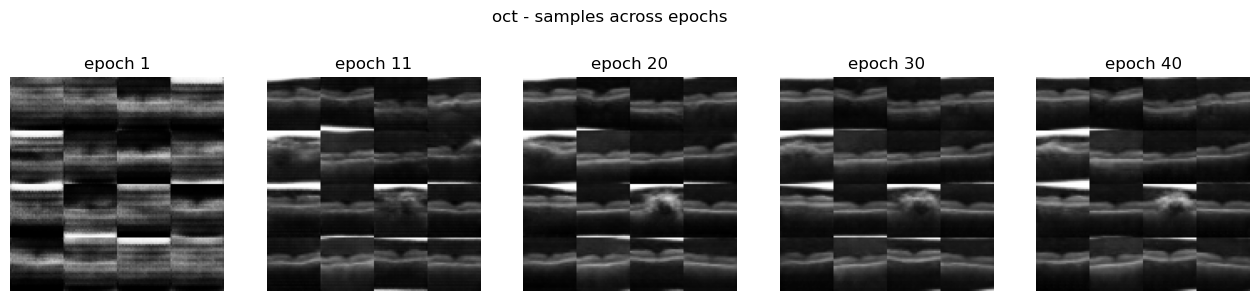

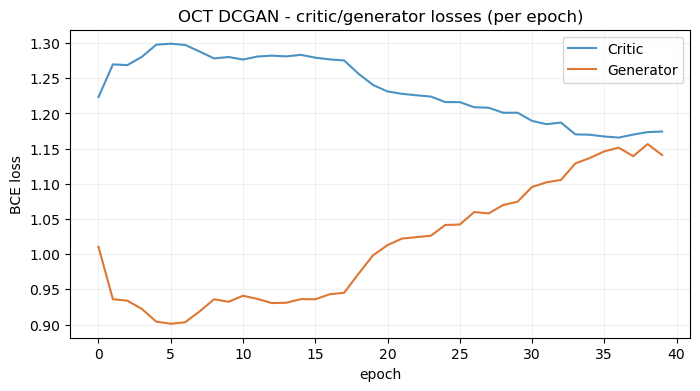

In [15]:
oct_generator, oct_d_losses, oct_g_losses = fit_image_gan(
    oct_generator, oct_critic, oct_images, OCT_EPOCHS, OCT_LATENT, "oct")
plot_loss_history(oct_d_losses, oct_g_losses, "OCT DCGAN - critic/generator losses (per epoch)", "oct_losses.png")

## 2.1.4 - Evaluation: real vs generated, and FID

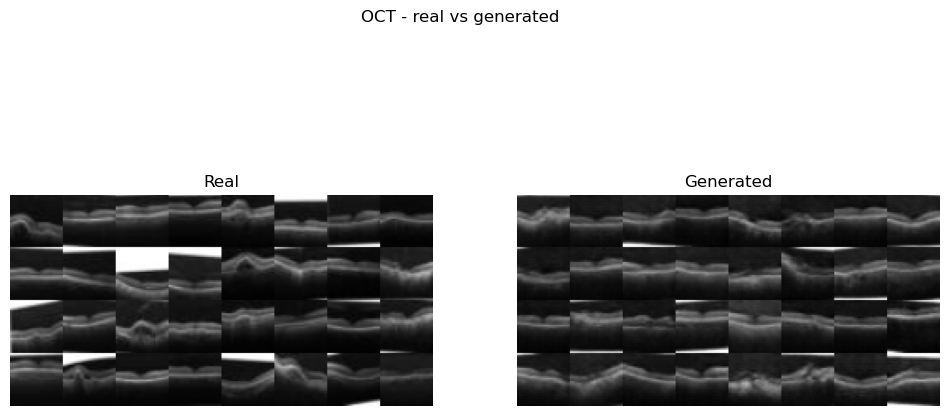

OCT DCGAN: FID = 44.89


In [16]:
frechet = FrechetInception()

oct_fake = oct_generator(tf.random.normal([2000, OCT_LATENT]), training=False).numpy()
show_real_fake(oct_images[:32], oct_fake[:32], "OCT - real vs generated", "oct_real_vs_fake.png")
oct_fid = report_fid(frechet, oct_images, oct_fake, "OCT DCGAN")

## 2.1 extension - Conditional GAN (Functional API)

For the extension I made the GAN class-aware. The generator concatenates a class embedding onto the latent vector. The critic uses **late-fusion** conditioning: it runs the image through the convolutions on its own and mixes in a small class embedding only at the final dense layer. Feeding the label in as a full extra image channel made the critic far too strong, so this keeps the class cue weak. It trains with instance noise on the images, a slower critic learning rate (two-time-scale), and two generator updates per critic update.

In [17]:
def oct_cgan_generator_net(latent_dim, num_classes):
    """Conditional generator: label embedding is concatenated onto the latent vector."""
    noise = keras.Input(shape=(latent_dim,), name="z")
    label = keras.Input(shape=(1,), dtype="int32", name="label")
    label_vec = layers.Flatten()(layers.Embedding(num_classes, 50)(label))
    x = layers.Concatenate()([noise, label_vec])
    x = layers.Dense(4 * 4 * 256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((4, 4, 256))(x)
    x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    image = layers.Conv2DTranspose(1, 4, strides=2, padding="same", use_bias=False, activation="tanh")(x)
    return keras.Model([noise, label], image, name="oct_cgan_generator")


def oct_cgan_critic_net(num_classes):
    """Conditional critic with LATE-FUSION conditioning: the image is processed on its
    own, and a small label embedding is mixed in only at the final dense layer. Feeding
    the label as a full image channel made the critic far too strong, so it is avoided."""
    image = keras.Input(shape=(32, 32, 1), name="image")
    label = keras.Input(shape=(1,), dtype="int32", name="label")
    x = layers.Conv2D(32, 4, strides=2, padding="same")(image)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(64, 4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(128, 4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    label_vec = layers.Flatten()(layers.Embedding(num_classes, 32)(label))
    x = layers.Concatenate()([x, label_vec])
    x = layers.Dropout(0.4)(x)
    logit = layers.Dense(1)(x)
    return keras.Model([image, label], logit, name="oct_cgan_critic")

[oct-cgan] epoch   1/40 | D=1.360 | G=0.895
[oct-cgan] epoch   2/40 | D=1.302 | G=1.017
[oct-cgan] epoch   3/40 | D=1.400 | G=1.031
[oct-cgan] epoch   4/40 | D=1.221 | G=1.065
[oct-cgan] epoch   5/40 | D=1.228 | G=1.006
[oct-cgan] epoch   6/40 | D=1.102 | G=0.957
[oct-cgan] epoch   7/40 | D=1.260 | G=1.156
[oct-cgan] epoch   8/40 | D=1.155 | G=1.317
[oct-cgan] epoch   9/40 | D=1.176 | G=1.175
[oct-cgan] epoch  10/40 | D=1.263 | G=1.267
[oct-cgan] epoch  11/40 | D=1.290 | G=1.218
[oct-cgan] epoch  12/40 | D=1.101 | G=1.243
[oct-cgan] epoch  13/40 | D=1.254 | G=1.305
[oct-cgan] epoch  14/40 | D=1.256 | G=1.236
[oct-cgan] epoch  15/40 | D=1.244 | G=1.050
[oct-cgan] epoch  16/40 | D=1.281 | G=1.293
[oct-cgan] epoch  17/40 | D=1.150 | G=1.423
[oct-cgan] epoch  18/40 | D=1.194 | G=1.027
[oct-cgan] epoch  19/40 | D=1.247 | G=1.081
[oct-cgan] epoch  20/40 | D=0.998 | G=1.168
[oct-cgan] epoch  21/40 | D=1.227 | G=1.190
[oct-cgan] epoch  22/40 | D=1.076 | G=1.547
[oct-cgan] epoch  23/40 | D=0.93

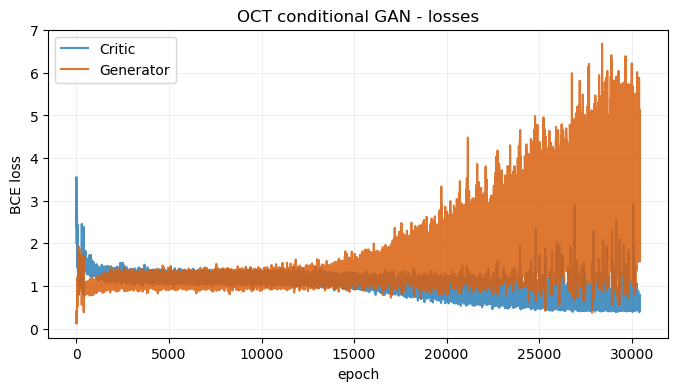

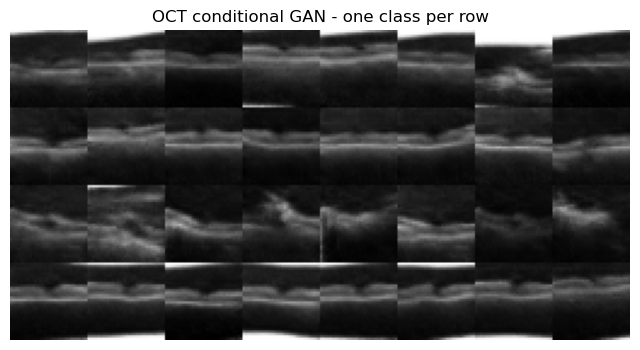

  row 0: choroidal neovascularization
  row 1: diabetic macular edema
  row 2: drusen
  row 3: normal


In [18]:
def fit_oct_cgan(images_signed, labels, epochs, latent_dim, num_classes, batch_size=128):
    """Conditional GAN trainer. To stop the critic dominating it uses instance noise on
    the images, a two-time-scale rule (critic learns slower) and two generator updates
    per critic update."""
    seed_keras()
    generator = oct_cgan_generator_net(latent_dim, num_classes)
    critic = oct_cgan_critic_net(num_classes)
    g_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)
    d_opt = keras.optimizers.Adam(1e-4, beta_1=0.5)

    @tf.function
    def step(real_images, real_labels, noise_std):
        batch = tf.shape(real_images)[0]
        z = tf.random.normal([batch, latent_dim])
        sampled = tf.random.uniform([batch, 1], 0, num_classes, dtype=tf.int32)
        fake_images = generator([z, sampled], training=True)
        real_noisy = real_images + tf.random.normal(tf.shape(real_images)) * noise_std
        fake_noisy = fake_images + tf.random.normal(tf.shape(fake_images)) * noise_std
        with tf.GradientTape() as d_tape:
            real_logits = critic([real_noisy, real_labels], training=True)
            fake_logits = critic([fake_noisy, sampled], training=True)
            d_loss = (LOGIT_BCE(tf.ones_like(real_logits) * 0.9, real_logits)
                      + LOGIT_BCE(tf.zeros_like(fake_logits), fake_logits))
        d_opt.apply_gradients(zip(d_tape.gradient(d_loss, critic.trainable_variables),
                                  critic.trainable_variables))
        g_loss = 0.0
        for _ in range(2):
            z = tf.random.normal([batch, latent_dim])
            sampled = tf.random.uniform([batch, 1], 0, num_classes, dtype=tf.int32)
            with tf.GradientTape() as g_tape:
                gen = generator([z, sampled], training=True)
                gen_noisy = gen + tf.random.normal(tf.shape(gen)) * noise_std
                fake_logits = critic([gen_noisy, sampled], training=True)
                g_loss = LOGIT_BCE(tf.ones_like(fake_logits), fake_logits)
            g_opt.apply_gradients(zip(g_tape.gradient(g_loss, generator.trainable_variables),
                                      generator.trainable_variables))
        return d_loss, g_loss

    dataset = to_dataset(images_signed, batch_size, labels=labels.reshape(-1, 1))
    d_losses, g_losses = [], []
    for epoch in range(1, epochs + 1):
        noise_std = tf.constant(0.1 * max(0.0, 1.0 - epoch / epochs), tf.float32)
        for real_batch, label_batch in dataset:
            d_loss, g_loss = step(real_batch, label_batch, noise_std)
            d_losses.append(float(d_loss)); g_losses.append(float(g_loss))
        print(f"[oct-cgan] epoch {epoch:>3}/{epochs} | D={float(d_loss):.3f} | G={float(g_loss):.3f}")
    return generator, d_losses, g_losses


oct_cgan_generator, oct_cgan_d, oct_cgan_g = fit_oct_cgan(
    oct_images, oct_labels, OCT_EPOCHS, OCT_LATENT, OCT_NUM_CLASSES)
plot_loss_history(oct_cgan_d, oct_cgan_g, "OCT conditional GAN - losses", "oct_cgan_losses.png")

_class_rows = []
for _cls in range(OCT_NUM_CLASSES):
    _z = tf.random.normal([8, OCT_LATENT])
    _lbl = tf.fill([8, 1], _cls)
    _class_rows.append(oct_cgan_generator([_z, _lbl], training=False).numpy())
show_samples(np.concatenate(_class_rows, axis=0), "OCT conditional GAN - one class per row",
             "oct_cgan_per_class.png", cols=8)
for _cls in range(OCT_NUM_CLASSES):
    print(f"  row {_cls}: {OCT_CLASS_NAMES[str(_cls)]}")

## 2.1 reflection

**Realism.** The generated scans capture the main structure: a bright, curved retinal band over a darker background, and the batch varies in the shape and position of that band rather than reprinting one image. The FID reported above shows how close the generated feature statistics land to the real ones.

**The conditional model.** The per-class samples look different from one row to the next, so the class embedding is genuinely being used rather than ignored. The classes that appear most often in the training set come out looking the most convincing, which is what I would expect given how imbalanced OCTMNIST is.

**Keeping the conditional model stable.** My first attempt at the conditional GAN was the odd one out: the critic overpowered the generator, its loss flat-lined at a low value while the generator loss ran away. The cause was how the label reached the critic - fed in as a full 32x32 image channel, it was such a strong cue that the critic could tell real from fake almost perfectly. The fix was late-fusion conditioning (the small label embedding is only mixed in at the final dense layer), plus instance noise on the images, a slower critic learning rate, and two generator steps per critic step. With those changes the two losses trade off in a healthy band (see the curve above) instead of one side running away, and the per-class rows stay distinct.

**Where it falls short.** The obvious remaining gap is fine texture. The generated scans are a bit too smooth and miss some of the speckle and sub-layer detail the real ones have, even though the overall band shape is captured well.

**On GANs "hallucinating" (the duck point).** The nickname comes from the duck test: if it looks like a duck and quacks like a duck, call it a duck. Even a low-FID GAN like this one is only trained to pass that surface-level test. The critic has no idea what is anatomically correct, so a confident, realistic-looking structure can still correspond to nothing in any real image. For a retinal scan that could mean inventing a bright patch that resembles pathology when none was there, or smoothing away a genuine feature. That is exactly why synthetic scans like these belong in data augmentation or teaching, not in actual diagnosis, no matter how good the FID looks. A low FID says the overall statistics match, not that any single image can be trusted.

# Part 2.2 - Cybersecurity: synthetic traffic with CICIDS 2017 (TensorFlow/Keras)

CICIDS 2017 describes each network flow with about 78 numeric features rather than an image, so here the GAN is a plain dense (fully-connected) network. It reuses the same `GanTrainer` class as the image GANs (the adversarial update is identical - only the generator and critic architectures change), with a latent dimension of 56.

The plan follows the brief: combine the per-day CSVs and look at the class balance, then focus on the Wednesday file, train a GAN on those feature vectors, and compare the real and synthetic data with PCA, t-SNE and a couple of alignment metrics. The extension then retrains on every day.

> **Data setup.** The eight CICIDS 2017 CSV files are loaded automatically: the notebook first looks in its own folder, and if they are not there it downloads the dataset from Kaggle, so there is nothing to edit by hand.
>
> **A note on the labels.** The brief says "DDoS", but the attacks in the Wednesday file are actually single-source DoS (Hulk, GoldenEye, slowloris, Slowhttptest). The real DDoS flows live in the Friday afternoon file. I have followed the named day and modelled Wednesday as BENIGN vs DoS, but I am flagging the mismatch here so it is clear I noticed it.

In [19]:
TABULAR_LATENT = 56
print(f"CICIDS feature-vector GAN latent dim = {TABULAR_LATENT}")

CICIDS feature-vector GAN latent dim = 56


## 2.2.1 - Finding the CSV files

In [20]:
import os
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ------------------------------------------------------------------ #
# The eight CICIDS 2017 day-files.
#   1. First look for the CSVs in the folder this notebook lives in.
#   2. If they are not there, download the dataset from Kaggle (kagglehub).
# Each location is searched recursively, since the files can sit inside
# a dataset sub-folder rather than at the top level.
# ------------------------------------------------------------------ #
CICIDS_CSV_FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]

def _resolve_cicids_files(base_dir):
    """Find every day-file anywhere under base_dir. Returns the list of full
    paths (ordered like CICIDS_CSV_FILES) only if all eight are present."""
    if not base_dir or not os.path.isdir(base_dir):
        return None
    found = {}
    for root, _dirs, files in os.walk(base_dir):
        for name in files:
            if name in CICIDS_CSV_FILES and name not in found:
                found[name] = os.path.join(root, name)
    if all(name in found for name in CICIDS_CSV_FILES):
        return [found[name] for name in CICIDS_CSV_FILES]
    return None

# 1) local directory that holds this notebook
cicids_csv_paths = _resolve_cicids_files(os.getcwd())
if cicids_csv_paths is not None:
    print("Loading the CICIDS 2017 CSV files from the local directory.")
else:
    # 2) fall back to downloading the dataset from Kaggle
    import kagglehub
    kaggle_dir = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    cicids_csv_paths = _resolve_cicids_files(kaggle_dir)
    if cicids_csv_paths is None:
        raise FileNotFoundError(
            "Could not find the eight CICIDS 2017 CSV files in the local directory "
            "or in the Kaggle dataset."
        )
    print("Loading the CICIDS 2017 CSV files from Kaggle.")

print(f"Found all {len(cicids_csv_paths)} CICIDS 2017 day-files:")
for csv_path in cicids_csv_paths:
    print("  ", os.path.basename(csv_path))


Loading the CICIDS 2017 CSV files from the local directory.
Found all 8 CICIDS 2017 day-files:
   Monday-WorkingHours.pcap_ISCX.csv
   Tuesday-WorkingHours.pcap_ISCX.csv
   Wednesday-workingHours.pcap_ISCX.csv
   Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
   Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
   Friday-WorkingHours-Morning.pcap_ISCX.csv
   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


## 2.2.2 - Combining the day files and exploring (EDA)

All eight files get concatenated into one frame, with each row tagged by the day it came from (`SourceDay`). Then I look at the overall class balance, how many flows come from each day, the feature count, how many `Inf`/`NaN` values need cleaning, and the fraction of attack traffic per day. CICIDS is very imbalanced (BENIGN swamps everything), so the counts are plotted on a log scale, and the numeric columns are downcast to float32 to keep the memory down.

In [21]:
def day_from_path(csv_path):
    """Read the day-of-week out of a CICIDS filename."""
    lowered = os.path.basename(csv_path).lower()
    for day in ("monday", "tuesday", "wednesday", "thursday", "friday"):
        if day in lowered:
            return day.capitalize()
    return "Unknown"


per_day_frames = []
for csv_path in cicids_csv_paths:
    frame = pd.read_csv(csv_path, low_memory=False)
    frame.columns = frame.columns.str.strip()
    frame = frame.loc[:, ~frame.columns.str.startswith("Unnamed")]
    if "Label" not in frame.columns:
        print(f"  skipping {os.path.basename(csv_path)} (no Label column)")
        continue
    numeric_cols = frame.select_dtypes(include=[np.number]).columns
    frame[numeric_cols] = frame[numeric_cols].astype(np.float32)
    frame["Label"] = frame["Label"].astype(str).str.strip()
    frame["SourceDay"] = day_from_path(csv_path)
    per_day_frames.append(frame)

if not per_day_frames:
    raise ValueError("No CICIDS day files with a Label column were found.")

# join="inner" keeps only the columns shared by every file, so a schema mismatch can't
# inject all-NaN columns that would later wipe rows on dropna().
combined_frame = pd.concat(per_day_frames, ignore_index=True, join="inner")
del per_day_frames
print(f"Combined dataset: {combined_frame.shape[0]:,} flows x {combined_frame.shape[1]} columns")

Combined dataset: 2,830,743 flows x 80 columns


Overall class distribution (all days):
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


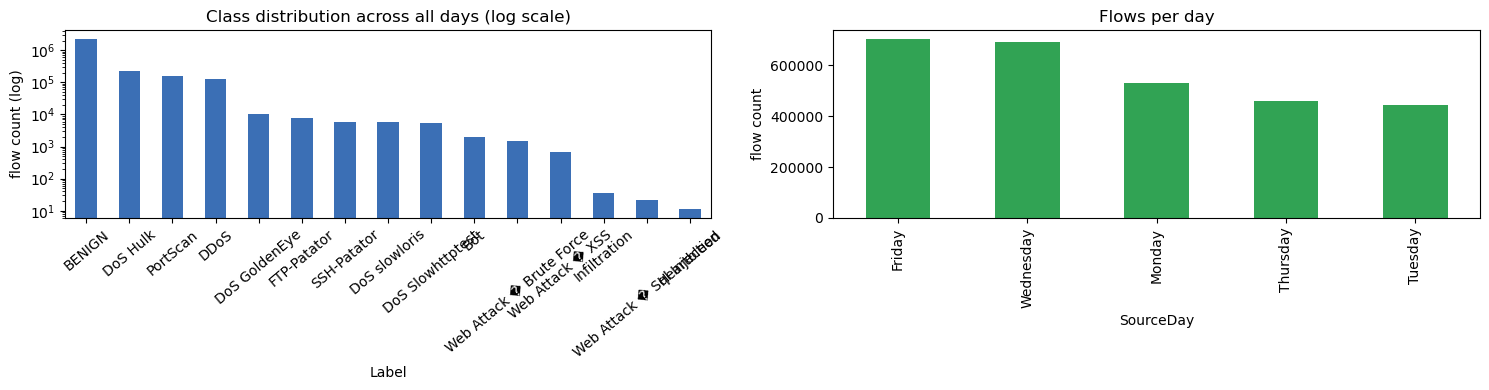

In [22]:
overall_distribution = combined_frame["Label"].value_counts()
print("Overall class distribution (all days):")
print(overall_distribution)

eda_figure, eda_axes = plt.subplots(1, 2, figsize=(15, 4))
overall_distribution.plot(kind="bar", ax=eda_axes[0], color="#3b6fb5", logy=True)
eda_axes[0].set_title("Class distribution across all days (log scale)")
eda_axes[0].set_ylabel("flow count (log)")
eda_axes[0].tick_params(axis="x", rotation=40)
combined_frame["SourceDay"].value_counts().plot(kind="bar", ax=eda_axes[1], color="#31a354")
eda_axes[1].set_title("Flows per day"); eda_axes[1].set_ylabel("flow count")
eda_figure.tight_layout()
eda_figure.savefig(os.path.join(RESULTS_DIR, "cicids_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

In [23]:
cicids_feature_columns = combined_frame.drop(columns=["Label", "SourceDay"]).select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric feature count: {len(cicids_feature_columns)}")
print("First 12 features:", cicids_feature_columns[:12])

numeric_block = combined_frame[cicids_feature_columns].to_numpy()
print(f"Infinite values across features: {int(np.isinf(numeric_block).sum()):,}")
print(f"Missing (NaN) values across features: {int(np.isnan(numeric_block).sum()):,}")
del numeric_block

attack_fraction_by_day = (
    combined_frame.assign(_is_attack=(combined_frame["Label"] != "BENIGN").astype(int))
    .groupby("SourceDay")["_is_attack"].mean().sort_values()
)
print("Fraction of attack flows per day:")
print(attack_fraction_by_day)

Numeric feature count: 78
First 12 features: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min']
Infinite values across features: 4,376
Missing (NaN) values across features: 1,358
Fraction of attack flows per day:
SourceDay
Monday       0.000000
Thursday     0.004828
Tuesday      0.031027
Wednesday    0.364762
Friday       0.410843
Name: _is_attack, dtype: float64


## 2.2.3 - Focusing on Wednesday (BENIGN vs DoS) and preprocessing

The GAN itself only trains on the Wednesday rows (`SourceDay == "Wednesday"`). I drop the `Inf`/`NaN` rows first, build a binary BENIGN-vs-DoS target, and keep the numeric features. Because CICIDS has some wild outliers, I scale the features with a RobustScaler (median and IQR, so no Gaussian assumption) and then clip to +/-5. Without that clipping the extreme values tend to destabilise training.

In [24]:
wednesday_frame = combined_frame[combined_frame["SourceDay"] == "Wednesday"].copy()
if wednesday_frame.empty:
    raise ValueError("No Wednesday rows in the combined dataset - check the file names.")

print("Wednesday class balance:")
print(wednesday_frame["Label"].value_counts())

wednesday_frame = wednesday_frame.replace([np.inf, -np.inf], np.nan).dropna()
if wednesday_frame.empty:
    raise ValueError("Wednesday data is empty after Inf/NaN cleaning - unexpected here.")

attack_indicator = (wednesday_frame["Label"] != "BENIGN").astype(int).to_numpy()
feature_frame = (wednesday_frame.drop(columns=["Label", "SourceDay"], errors="ignore")
                 .select_dtypes(include=[np.number]).astype(np.float32))
feature_names = list(feature_frame.columns)
feature_matrix = feature_frame.to_numpy()
print(f"Feature vectors: {feature_matrix.shape[0]} rows x {feature_matrix.shape[1]} features")

from sklearn.preprocessing import RobustScaler

_scaler = RobustScaler().fit(feature_matrix)


def apply_scaler(matrix):
    """Median/IQR scaling (robust to outliers), then clip to +/-5."""
    return np.clip(_scaler.transform(matrix), -5.0, 5.0).astype(np.float32)


scaled_features = apply_scaler(feature_matrix)

Wednesday class balance:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64
Feature vectors: 691406 rows x 78 features


In [25]:
seed_keras()
cicids_row_cap = 20000
cicids_row_indices = np.random.permutation(scaled_features.shape[0])[:cicids_row_cap]
cicids_training_features = scaled_features[cicids_row_indices]
cicids_feature_dim = cicids_training_features.shape[1]
print(f"Training the tabular GAN on {cicids_training_features.shape[0]} rows x {cicids_feature_dim} features")

Training the tabular GAN on 20000 rows x 78 features


## 2.2.4 - The feature-vector GAN (dense), trained with the shared GanTrainer

The generator maps the latent noise to a whole feature vector, with a linear output layer since the scaled features are not bounded. The critic is a dense network with dropout that returns a single logit. Both are wrapped in the same `GanTrainer` class used by the image GANs and trained with `model.fit`, so the training code is not duplicated.

In [26]:
def tabular_generator_net(latent_dim, feature_dim):
    """Dense generator (BatchNorm + LeakyReLU), widths 128 -> 256 -> 128 -> feature_dim."""
    noise = keras.Input(shape=(latent_dim,))
    x = layers.Dense(128)(noise)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)
    vector = layers.Dense(feature_dim)(x)
    return keras.Model(noise, vector, name="tabular_generator")


def tabular_critic_net(feature_dim):
    """Dense critic with dropout, two hidden layers of width 160."""
    vector = keras.Input(shape=(feature_dim,))
    x = layers.Dense(160)(vector); x = layers.LeakyReLU(0.2)(x); x = layers.Dropout(0.3)(x)
    x = layers.Dense(160)(x); x = layers.LeakyReLU(0.2)(x); x = layers.Dropout(0.3)(x)
    logit = layers.Dense(1)(x)
    return keras.Model(vector, logit, name="tabular_critic")

In [27]:
def fit_tabular_gan(features, epochs, latent_dim, batch_size=256):
    """Train a feature-vector GAN by reusing the shared GanTrainer subclass."""
    seed_keras()
    generator = tabular_generator_net(latent_dim, features.shape[1])
    critic = tabular_critic_net(features.shape[1])
    trainer = GanTrainer(generator, critic, latent_dim)
    trainer.compile(keras.optimizers.Adam(2e-4, beta_1=0.5),
                    keras.optimizers.Adam(2e-4, beta_1=0.5), LOGIT_BCE)
    history = trainer.fit(to_dataset(features.astype("float32"), batch_size),
                          epochs=epochs, verbose=2, shuffle=False)
    return generator, history.history["d_loss"], history.history["g_loss"]

Epoch 1/60


I0000 00:00:1785436668.212584  148680 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_277122__.48
I0000 00:00:1785436668.375174  148680 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1785436669.022658  148680 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1785436669.778192  148680 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1785436670.7646

78/78 - 20s - 252ms/step - d_loss: 1.2060 - g_loss: 0.9450
Epoch 2/60
78/78 - 0s - 2ms/step - d_loss: 1.2738 - g_loss: 0.8240
Epoch 3/60
78/78 - 0s - 2ms/step - d_loss: 1.1830 - g_loss: 0.9630
Epoch 4/60
78/78 - 0s - 2ms/step - d_loss: 1.1995 - g_loss: 0.9719
Epoch 5/60
78/78 - 0s - 2ms/step - d_loss: 1.2305 - g_loss: 0.9618
Epoch 6/60
78/78 - 0s - 2ms/step - d_loss: 1.2220 - g_loss: 1.0041
Epoch 7/60
78/78 - 0s - 2ms/step - d_loss: 1.2041 - g_loss: 1.0350
Epoch 8/60
78/78 - 0s - 2ms/step - d_loss: 1.1601 - g_loss: 1.1018
Epoch 9/60
78/78 - 0s - 2ms/step - d_loss: 1.1538 - g_loss: 1.0878
Epoch 10/60
78/78 - 0s - 2ms/step - d_loss: 1.1588 - g_loss: 1.0849
Epoch 11/60
78/78 - 0s - 2ms/step - d_loss: 1.1553 - g_loss: 1.0878
Epoch 12/60
78/78 - 0s - 2ms/step - d_loss: 1.1437 - g_loss: 1.1343
Epoch 13/60
78/78 - 0s - 2ms/step - d_loss: 1.1501 - g_loss: 1.1513
Epoch 14/60
78/78 - 0s - 2ms/step - d_loss: 1.1564 - g_loss: 1.1528
Epoch 15/60
78/78 - 0s - 2ms/step - d_loss: 1.1596 - g_loss: 1.14

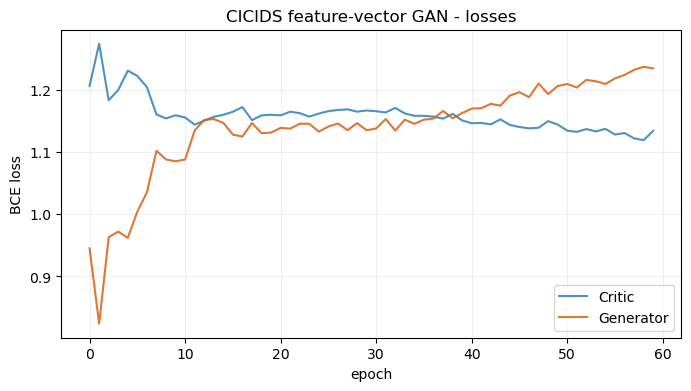

In [28]:
cicids_epochs = 60
cicids_generator, cicids_d_losses, cicids_g_losses = fit_tabular_gan(
    cicids_training_features, cicids_epochs, TABULAR_LATENT)
plot_loss_history(cicids_d_losses, cicids_g_losses, "CICIDS feature-vector GAN - losses", "cicids_loss_curves.png")

## 2.2.5 - Comparing the real and synthetic distributions (PCA, t-SNE, alignment gaps)

To see how close the synthetic data is, I project both real and generated vectors down to 2D. PCA gives a quick linear view (real BENIGN, real DoS and synthetic coloured separately), and t-SNE gives a non-linear view that shows the local structure better. On top of the plots I compute two alignment gaps: the mean absolute difference in per-feature means and in per-feature standard deviations, which put a number on how well the marginals line up.

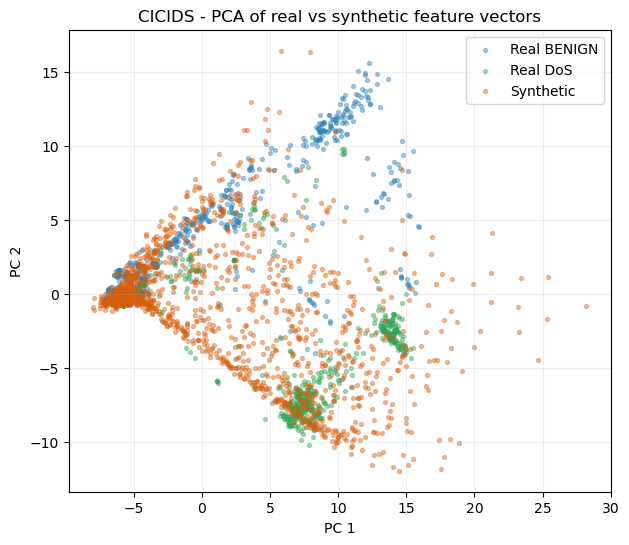

In [29]:
def sample_tabular(generator, count):
    return generator(tf.random.normal([count, TABULAR_LATENT]), training=False).numpy()


cicids_eval_count = 2000
_real_idx = np.random.permutation(scaled_features.shape[0])[:cicids_eval_count]
cicids_real = scaled_features[_real_idx]
cicids_real_labels = attack_indicator[_real_idx]
cicids_synthetic = sample_tabular(cicids_generator, cicids_eval_count)

cicids_pca = PCA(n_components=2).fit(cicids_real)
real_pca = cicids_pca.transform(cicids_real)
synth_pca = cicids_pca.transform(cicids_synthetic)

plt.figure(figsize=(7, 6))
plt.scatter(real_pca[cicids_real_labels == 0, 0], real_pca[cicids_real_labels == 0, 1],
            s=8, alpha=0.4, label="Real BENIGN", color="#2c7fb8")
plt.scatter(real_pca[cicids_real_labels == 1, 0], real_pca[cicids_real_labels == 1, 1],
            s=8, alpha=0.4, label="Real DoS", color="#31a354")
plt.scatter(synth_pca[:, 0], synth_pca[:, 1], s=8, alpha=0.4, label="Synthetic", color="#d95f0e")
plt.title("CICIDS - PCA of real vs synthetic feature vectors")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.legend(); plt.grid(alpha=0.2)
plt.savefig(os.path.join(RESULTS_DIR, "cicids_pca.png"), dpi=150, bbox_inches="tight")
plt.show()

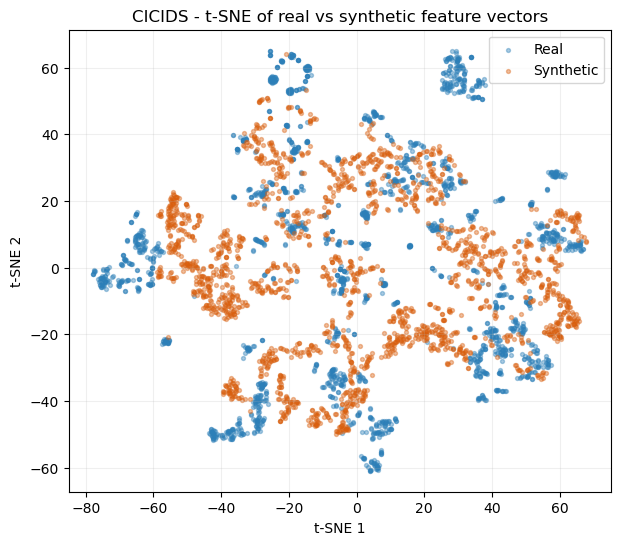

In [30]:
tsne_input = np.vstack([cicids_real, cicids_synthetic])
tsne_xy = TSNE(n_components=2, perplexity=30, init="pca", random_state=KERAS_SEED).fit_transform(tsne_input)
real_tsne = tsne_xy[:cicids_eval_count]
synth_tsne = tsne_xy[cicids_eval_count:]

plt.figure(figsize=(7, 6))
plt.scatter(real_tsne[:, 0], real_tsne[:, 1], s=8, alpha=0.4, label="Real", color="#2c7fb8")
plt.scatter(synth_tsne[:, 0], synth_tsne[:, 1], s=8, alpha=0.4, label="Synthetic", color="#d95f0e")
plt.title("CICIDS - t-SNE of real vs synthetic feature vectors")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.legend(); plt.grid(alpha=0.2)
plt.savefig(os.path.join(RESULTS_DIR, "cicids_tsne.png"), dpi=150, bbox_inches="tight")
plt.show()

CICIDS alignment gap | mean |dmu| = 0.1128 | mean |dsigma| = 0.1870


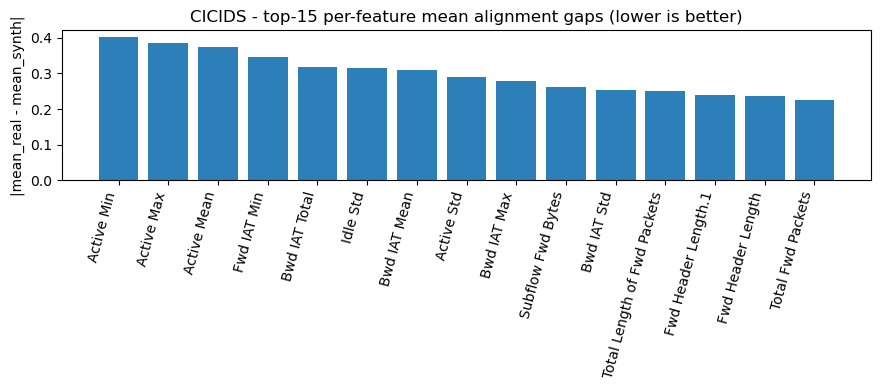

In [31]:
def distribution_gaps(real_features, fake_features):
    """Mean absolute per-feature differences in mean and std (lower = better aligned)."""
    mean_gap = np.abs(real_features.mean(0) - fake_features.mean(0))
    std_gap = np.abs(real_features.std(0) - fake_features.std(0))
    return mean_gap, std_gap


cicids_mean_gap, cicids_std_gap = distribution_gaps(cicids_real, cicids_synthetic)
print(f"CICIDS alignment gap | mean |dmu| = {cicids_mean_gap.mean():.4f} "
      f"| mean |dsigma| = {cicids_std_gap.mean():.4f}")

top = np.argsort(cicids_mean_gap)[::-1][:15]
plt.figure(figsize=(9, 4))
plt.bar([feature_names[i] for i in top], cicids_mean_gap[top], color="#2c7fb8")
plt.title("CICIDS - top-15 per-feature mean alignment gaps (lower is better)")
plt.ylabel("|mean_real - mean_synth|"); plt.xticks(rotation=75, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cicids_alignment_gaps.png"), dpi=150, bbox_inches="tight")
plt.show()

## 2.2 extension - The full multi-day dataset and generalisation

For the extra credit I retrain the same dense GAN on the entire CICIDS 2017 dataset, all days and every attack type, to see whether one unconditional generator can spread across the many attack families or just collapses onto the dominant BENIGN mode. In the PCA plot the real points are coloured by attack family so it is easier to see where the synthetic points land.

In [32]:
def attack_family(label):
    """Collapse the fine-grained CICIDS labels into coarse families for colouring."""
    if label == "BENIGN":
        return "BENIGN"
    if label.startswith("DoS"):
        return "DoS"
    if label == "DDoS":
        return "DDoS"
    if label == "PortScan":
        return "PortScan"
    if label.startswith("Web Attack"):
        return "Web Attack"
    if label == "Bot":
        return "Bot"
    if label.startswith(("FTP", "SSH")):
        return "Brute Force"
    if label == "Infiltration":
        return "Infiltration"
    if label == "Heartbleed":
        return "Heartbleed"
    return "Other"


seed_keras()
full_clean = combined_frame.replace([np.inf, -np.inf], np.nan).dropna()
full_families = full_clean["Label"].map(attack_family).to_numpy()
full_matrix = (full_clean.drop(columns=["Label", "SourceDay"], errors="ignore")
               .select_dtypes(include=[np.number]).astype(np.float32).to_numpy())
# Reuse the Wednesday scaler so the two runs share a comparable feature scale.
full_scaled = apply_scaler(full_matrix)
del full_clean

full_row_cap = 30000
_full_subset = np.random.permutation(full_scaled.shape[0])[:full_row_cap]
full_training_features = full_scaled[_full_subset]
print(f"Training the full-dataset GAN on {full_training_features.shape[0]} rows sampled from all days")

Training the full-dataset GAN on 30000 rows sampled from all days


Epoch 1/60


I0000 00:00:1785436710.347313  148681 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_301380__.48


117/117 - 7s - 64ms/step - d_loss: 1.2267 - g_loss: 0.9112
Epoch 2/60
117/117 - 0s - 2ms/step - d_loss: 1.2263 - g_loss: 0.9035
Epoch 3/60
117/117 - 0s - 2ms/step - d_loss: 1.2531 - g_loss: 0.9292
Epoch 4/60
117/117 - 0s - 2ms/step - d_loss: 1.2498 - g_loss: 0.9523
Epoch 5/60
117/117 - 0s - 2ms/step - d_loss: 1.2136 - g_loss: 1.0115
Epoch 6/60
117/117 - 0s - 2ms/step - d_loss: 1.1860 - g_loss: 1.0460
Epoch 7/60
117/117 - 0s - 2ms/step - d_loss: 1.1700 - g_loss: 1.0605
Epoch 8/60
117/117 - 0s - 2ms/step - d_loss: 1.1687 - g_loss: 1.0837
Epoch 9/60
117/117 - 0s - 2ms/step - d_loss: 1.1399 - g_loss: 1.1180
Epoch 10/60
117/117 - 0s - 2ms/step - d_loss: 1.1443 - g_loss: 1.1177
Epoch 11/60
117/117 - 0s - 2ms/step - d_loss: 1.1512 - g_loss: 1.1328
Epoch 12/60
117/117 - 0s - 2ms/step - d_loss: 1.1469 - g_loss: 1.1357
Epoch 13/60
117/117 - 0s - 2ms/step - d_loss: 1.1516 - g_loss: 1.1362
Epoch 14/60
117/117 - 0s - 2ms/step - d_loss: 1.1476 - g_loss: 1.1497
Epoch 15/60
117/117 - 0s - 2ms/step - d

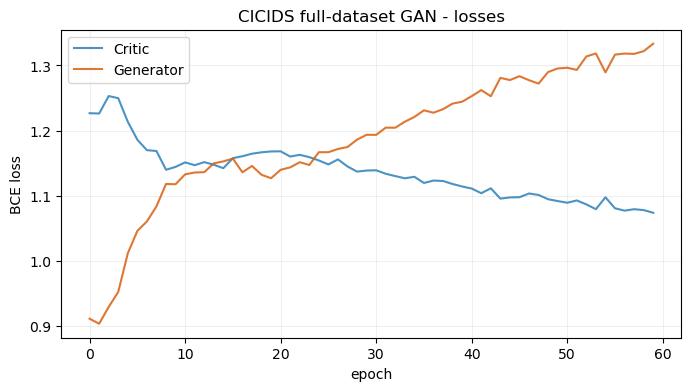

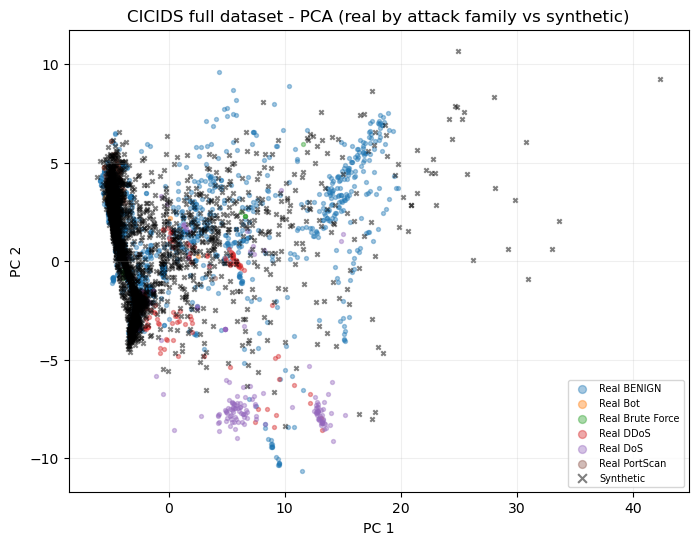

Full-dataset alignment gap | mean |dmu| = 0.1518 (Wednesday-only 0.1128)
Full-dataset alignment gap | mean |dsigma| = 0.2248 (Wednesday-only 0.1870)


In [33]:
full_generator, full_d_losses, full_g_losses = fit_tabular_gan(
    full_training_features, cicids_epochs, TABULAR_LATENT)
plot_loss_history(full_d_losses, full_g_losses, "CICIDS full-dataset GAN - losses", "cicids_full_loss_curves.png")

full_eval_count = 2500
_full_real_idx = np.random.permutation(full_scaled.shape[0])[:full_eval_count]
full_real = full_scaled[_full_real_idx]
full_real_families = full_families[_full_real_idx]
full_synthetic = sample_tabular(full_generator, full_eval_count)

full_pca = PCA(n_components=2).fit(full_real)
full_real_pca = full_pca.transform(full_real)
full_synth_pca = full_pca.transform(full_synthetic)

plt.figure(figsize=(8, 6))
for family in sorted(set(full_real_families)):
    mask = full_real_families == family
    plt.scatter(full_real_pca[mask, 0], full_real_pca[mask, 1], s=8, alpha=0.4, label=f"Real {family}")
plt.scatter(full_synth_pca[:, 0], full_synth_pca[:, 1], s=10, alpha=0.5,
            label="Synthetic", color="black", marker="x")
plt.title("CICIDS full dataset - PCA (real by attack family vs synthetic)")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.legend(fontsize=7, markerscale=2); plt.grid(alpha=0.2)
plt.savefig(os.path.join(RESULTS_DIR, "cicids_full_pca.png"), dpi=150, bbox_inches="tight")
plt.show()

full_mean_gap, full_std_gap = distribution_gaps(full_real, full_synthetic)
print(f"Full-dataset alignment gap | mean |dmu| = {full_mean_gap.mean():.4f} "
      f"(Wednesday-only {cicids_mean_gap.mean():.4f})")
print(f"Full-dataset alignment gap | mean |dsigma| = {full_std_gap.mean():.4f} "
      f"(Wednesday-only {cicids_std_gap.mean():.4f})")

## 2.2 reflection

**How well it lines up.** In both the PCA and t-SNE plots the generated points sit inside the main cluster of real data rather than off on their own, though the synthetic cloud is a bit more tightly packed than the real one. The alignment gaps printed above put numbers on this: a moderate gap, so the generator finds the rough location of the real distribution but does not fully reproduce its spread, especially for the more skewed, heavy-tailed features.

**The full dataset.** Training on all eight days (values printed above) tends to keep the mean-gap similar or better while the spread is still the harder thing to match. My reading is that BENIGN and the high-volume attacks dominate even with every day combined, so the generator keeps tracking the main modes, while the rare classes (Heartbleed, Infiltration, and so on) stay under-represented because there are so few of those rows.

**The label note again.** As mentioned above, the core Wednesday task is really DoS, not DDoS. True DDoS only appears once the Friday file is folded into the all-days extension, which is what the code does.

**"Ducks."** The duck-test idea carries over directly. A generated flow only has to convince the critic that it "looks statistically like real traffic", not that it reflects how a real attack actually works. A flow that looks plausible but matches no genuine attack or benign behaviour would be a real problem if you used it to augment intrusion-detection training data: it could teach a downstream model to expect attacks that do not look like the real thing, or to treat normal traffic as suspicious. And unlike an image, you cannot glance at a row of numbers and tell it is wrong, which is why the alignment gaps above (especially the std-gap, where this kind of subtle mismatch shows up first) are the main check I have.

# Part 2.3 - Creative AI: QuickDraw sketches (TensorFlow/Keras DCGAN)

For the last part I train a DCGAN on QuickDraw sketches, reusing the same `GanTrainer` class again. This generator is built the other way round from the OCT one - nearest-neighbour upsampling followed by a 3x3 convolution at each step instead of transposed convolutions - just to show a second common way of building a DCGAN generator. The latent dimension is 64. I track the losses, snapshot samples at a few epochs to watch it improve, and score the generator with FID. The extension runs the same model on a couple of other categories and checks whether FID lines up with a simple "how busy is the sketch" measure.

*(This section reuses `to_dataset`, `LOGIT_BCE`, the `GanTrainer` class and the FID scorer from earlier in Part 2.)*

In [34]:
SKETCH_LATENT = 64
SKETCH_EXTRA_CATEGORIES = ["cat", "house"]
SKETCH_EPOCHS = 30
print(f"QuickDraw sketch GAN: latent={SKETCH_LATENT} | extra categories={SKETCH_EXTRA_CATEGORIES}")

QuickDraw sketch GAN: latent=64 | extra categories=['cat', 'house']


## 2.3.1 - Downloading and exploring the 'birthday cake' category

birthday cake bitmaps: (144982, 28, 28)


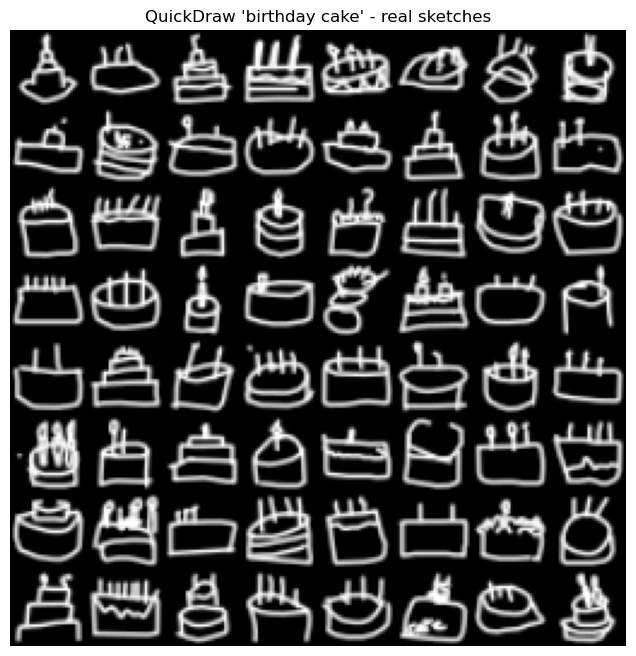

In [35]:
import urllib.request

QUICKDRAW_DIR = os.path.join(RESULTS_DIR, "quickdraw")
os.makedirs(QUICKDRAW_DIR, exist_ok=True)


def fetch_quickdraw(category):
    """Download a QuickDraw numpy-bitmap category -> (N, 28, 28) uint8 array."""
    url = ("https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"
           + category.replace(" ", "%20") + ".npy")
    local = os.path.join(QUICKDRAW_DIR, category.replace(" ", "_") + ".npy")
    if not os.path.exists(local):
        print("downloading QuickDraw category:", category)
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req) as resp, open(local, "wb") as fh:
            fh.write(resp.read())
    return np.load(local).reshape(-1, 28, 28)


def bitmaps_to_signed(uint8_images, size=32):
    """(N, 28, 28) uint8 -> (N, size, size, 1) float32 in [-1, 1]."""
    scaled = uint8_images.astype("float32")[..., None] / 127.5 - 1.0
    return tf.image.resize(scaled, (size, size)).numpy()


def ink_fraction(uint8_images, sample=3000):
    """Mean normalised ink coverage - a rough sketch-complexity proxy."""
    idx = np.random.permutation(len(uint8_images))[:sample]
    return float((uint8_images[idx].astype(np.float32) / 255.0).mean())


cake_uint8 = fetch_quickdraw("birthday cake")
cake_images = bitmaps_to_signed(cake_uint8)
print("birthday cake bitmaps:", cake_uint8.shape)
show_samples(cake_images[:64], "QuickDraw 'birthday cake' - real sketches", "qd_cake_real.png")

## 2.3.2 - The sketch DCGAN networks

`sketch_generator_net` and `sketch_critic_net` return the Functional DCGAN networks (upsample-then-convolve generator, strided-conv critic), and `fit_sketch_gan` trains them through the shared `GanTrainer` with a snapshot callback that grabs a grid of generated samples at a few epochs so I can show how the outputs develop.

In [36]:
def sketch_generator_net(latent_dim):
    """DCGAN generator using nearest-neighbour upsampling + conv: (latent,) -> (32, 32, 1)."""
    noise = keras.Input(shape=(latent_dim,))
    x = layers.Dense(4 * 4 * 256, use_bias=False)(noise)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Reshape((4, 4, 256))(x)
    x = layers.UpSampling2D()(x)                                        # 4 -> 8
    x = layers.Conv2D(128, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.UpSampling2D()(x)                                        # 8 -> 16
    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.UpSampling2D()(x)                                        # 16 -> 32
    image = layers.Conv2D(1, 3, padding="same", activation="tanh")(x)
    return keras.Model(noise, image, name="sketch_generator")


def sketch_critic_net():
    """DCGAN critic from strided convs + BatchNorm: (32, 32, 1) -> logit."""
    image = keras.Input(shape=(32, 32, 1))
    x = layers.Conv2D(64, 3, strides=2, padding="same")(image)         # 32 -> 16
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)            # 16 -> 8
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(256, 3, strides=2, padding="same")(x)            # 8 -> 4
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    logit = layers.Dense(1)(x)
    return keras.Model(image, logit, name="sketch_critic")

In [37]:
def fit_sketch_gan(images_signed, epochs, tag, batch_size=128):
    """Train a sketch DCGAN by reusing the shared image-GAN trainer."""
    generator = sketch_generator_net(SKETCH_LATENT)
    critic = sketch_critic_net()
    return fit_image_gan(generator, critic, images_signed, epochs, SKETCH_LATENT, f"qd_{tag}", batch_size)


def sample_sketch(generator, count):
    return generator(tf.random.normal([count, SKETCH_LATENT]), training=False).numpy()

## 2.3.3 - Training on 'birthday cake' and evaluating (FID)

Epoch 1/30


I0000 00:00:1785436734.905807  148680 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_336900__.71


1132/1132 - 22s - 19ms/step - d_loss: 0.4943 - g_loss: 3.1548
Epoch 2/30
1132/1132 - 8s - 7ms/step - d_loss: 0.4574 - g_loss: 3.8934
Epoch 3/30
1132/1132 - 8s - 7ms/step - d_loss: 0.3902 - g_loss: 4.5265
Epoch 4/30
1132/1132 - 8s - 7ms/step - d_loss: 0.4166 - g_loss: 4.5772
Epoch 5/30
1132/1132 - 8s - 7ms/step - d_loss: 0.3783 - g_loss: 5.0182
Epoch 6/30
1132/1132 - 8s - 7ms/step - d_loss: 0.3990 - g_loss: 5.0164
Epoch 7/30
1132/1132 - 8s - 7ms/step - d_loss: 0.3783 - g_loss: 5.0778
Epoch 8/30
1132/1132 - 8s - 7ms/step - d_loss: 0.3702 - g_loss: 5.3367
Epoch 9/30
1132/1132 - 8s - 7ms/step - d_loss: 0.3763 - g_loss: 5.3291
Epoch 10/30
1132/1132 - 8s - 7ms/step - d_loss: 0.3619 - g_loss: 5.5432
Epoch 11/30
1132/1132 - 8s - 7ms/step - d_loss: 0.3736 - g_loss: 5.2314
Epoch 12/30
1132/1132 - 8s - 7ms/step - d_loss: 0.3761 - g_loss: 5.5039
Epoch 13/30
1132/1132 - 8s - 7ms/step - d_loss: 0.3616 - g_loss: 5.8079
Epoch 14/30
1132/1132 - 8s - 7ms/step - d_loss: 0.3584 - g_loss: 5.5809
Epoch 15/3

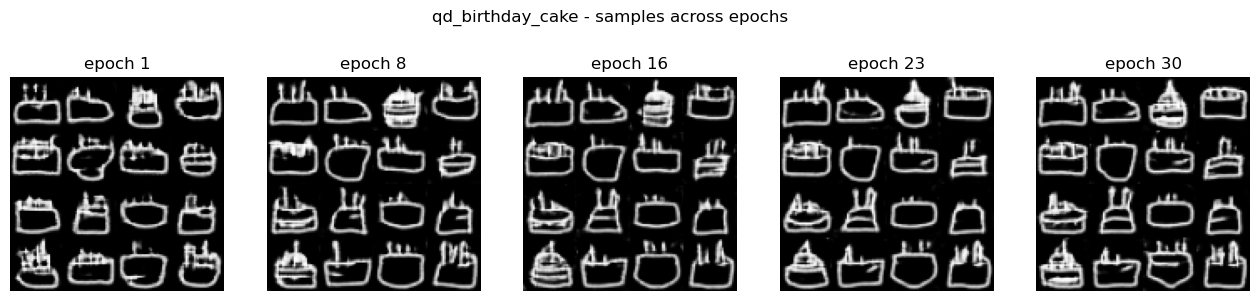

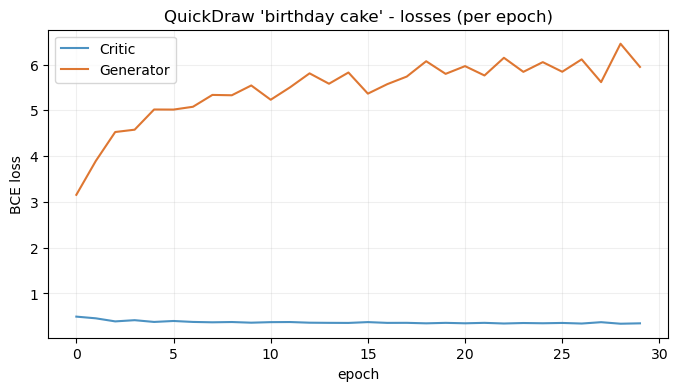

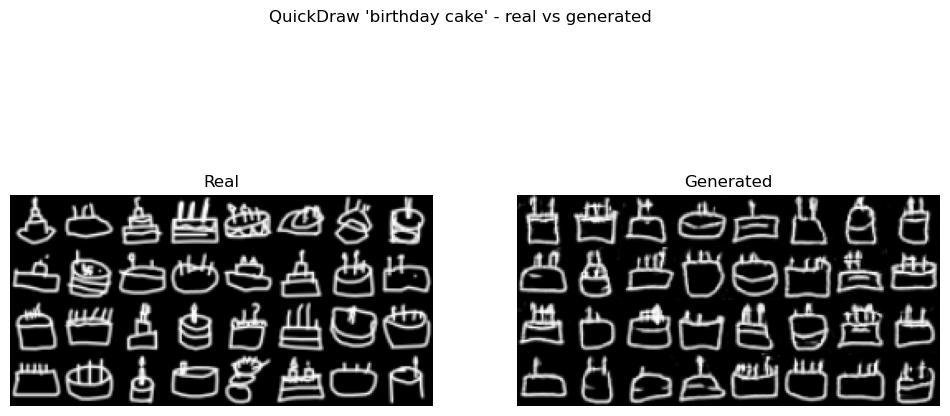

QuickDraw birthday cake: FID = 34.36


In [38]:
cake_generator, cake_d_losses, cake_g_losses = fit_sketch_gan(cake_images, SKETCH_EPOCHS, "birthday_cake")
plot_loss_history(cake_d_losses, cake_g_losses, "QuickDraw 'birthday cake' - losses (per epoch)", "qd_cake_losses.png")

cake_fake = sample_sketch(cake_generator, 2000)
show_real_fake(cake_images[:32], cake_fake[:32], "QuickDraw 'birthday cake' - real vs generated", "qd_cake_real_vs_fake.png")
cake_fid = report_fid(frechet, cake_images, cake_fake, "QuickDraw birthday cake")

## 2.3 extension - Other categories and sketch complexity

Here I train the same subclassed DCGAN on a few more QuickDraw categories. I then compare the FID against an ink-density measure (roughly how much of the image is actually drawn on). The intuition is that busier, denser sketches should be harder to model, so I would expect higher ink density to line up with higher FID.

Epoch 1/30


I0000 00:00:1785437012.614240  148675 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_486187__.71


962/962 - 15s - 15ms/step - d_loss: 0.5907 - g_loss: 2.5853
Epoch 2/30
962/962 - 7s - 7ms/step - d_loss: 0.4865 - g_loss: 3.5584
Epoch 3/30
962/962 - 7s - 7ms/step - d_loss: 0.4370 - g_loss: 3.9839
Epoch 4/30
962/962 - 7s - 7ms/step - d_loss: 0.4029 - g_loss: 4.4315
Epoch 5/30
962/962 - 7s - 7ms/step - d_loss: 0.4186 - g_loss: 4.6300
Epoch 6/30
962/962 - 7s - 7ms/step - d_loss: 0.3972 - g_loss: 4.7282
Epoch 7/30
962/962 - 7s - 7ms/step - d_loss: 0.3916 - g_loss: 4.9770
Epoch 8/30
962/962 - 7s - 7ms/step - d_loss: 0.3808 - g_loss: 5.2969
Epoch 9/30
962/962 - 7s - 7ms/step - d_loss: 0.3736 - g_loss: 5.2397
Epoch 10/30
962/962 - 7s - 7ms/step - d_loss: 0.3754 - g_loss: 5.2691
Epoch 11/30
962/962 - 7s - 7ms/step - d_loss: 0.3667 - g_loss: 5.5335
Epoch 12/30
962/962 - 7s - 7ms/step - d_loss: 0.3780 - g_loss: 5.3035
Epoch 13/30
962/962 - 7s - 7ms/step - d_loss: 0.3575 - g_loss: 5.6712
Epoch 14/30
962/962 - 7s - 7ms/step - d_loss: 0.3724 - g_loss: 5.6351
Epoch 15/30
962/962 - 7s - 7ms/step - 

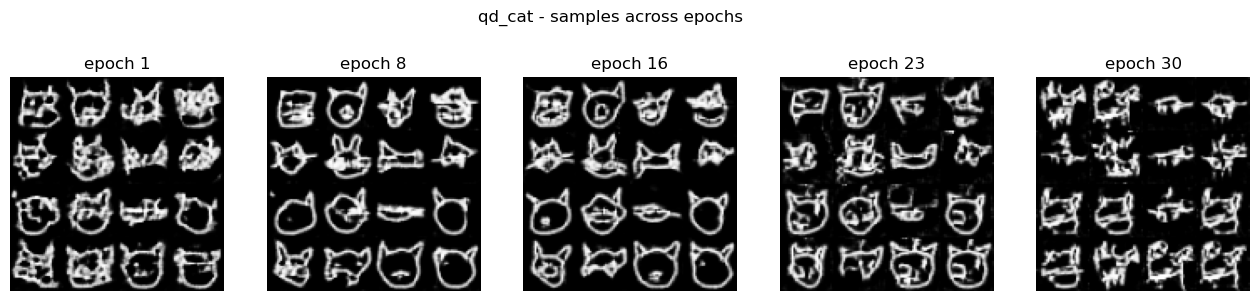

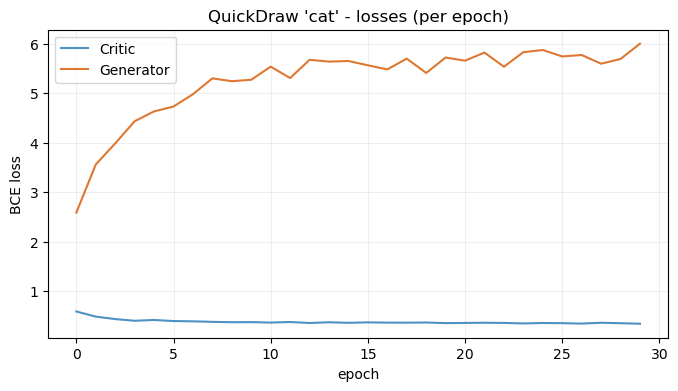

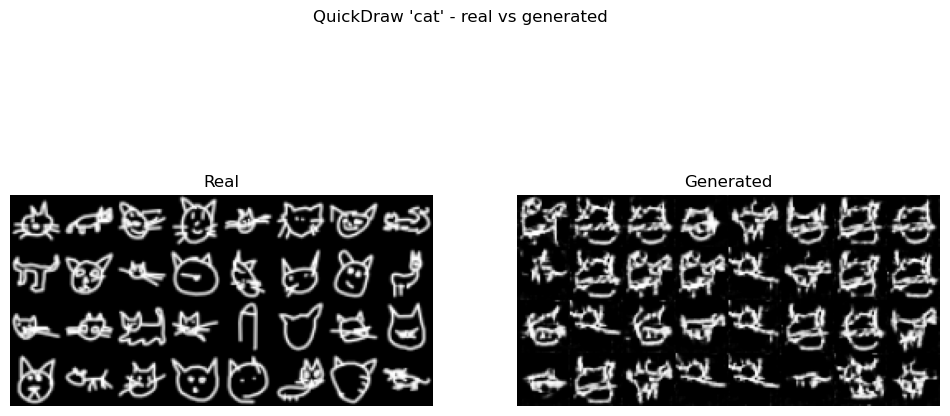

QuickDraw cat: FID = 113.66
Epoch 1/30


I0000 00:00:1785437247.909528  148680 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_615074__.71


1057/1057 - 16s - 15ms/step - d_loss: 0.4798 - g_loss: 3.3012
Epoch 2/30
1057/1057 - 8s - 7ms/step - d_loss: 0.4590 - g_loss: 3.6937
Epoch 3/30
1057/1057 - 8s - 7ms/step - d_loss: 0.4414 - g_loss: 3.9256
Epoch 4/30
1057/1057 - 8s - 7ms/step - d_loss: 0.4082 - g_loss: 4.3747
Epoch 5/30


In [ ]:
quickdraw_fid = {"birthday cake": cake_fid}
quickdraw_ink = {"birthday cake": ink_fraction(cake_uint8)}

for category in SKETCH_EXTRA_CATEGORIES:
    cat_uint8 = fetch_quickdraw(category)
    cat_images = bitmaps_to_signed(cat_uint8)
    quickdraw_ink[category] = ink_fraction(cat_uint8)
    cat_generator, cat_d, cat_g = fit_sketch_gan(cat_images, SKETCH_EPOCHS, category)
    plot_loss_history(cat_d, cat_g, f"QuickDraw '{category}' - losses (per epoch)", f"qd_{category}_losses.png")
    cat_fake = sample_sketch(cat_generator, 2000)
    show_real_fake(cat_images[:32], cat_fake[:32],
                   f"QuickDraw '{category}' - real vs generated", f"qd_{category}_real_vs_fake.png")
    quickdraw_fid[category] = report_fid(frechet, cat_images, cat_fake, f"QuickDraw {category}")

In [ ]:
category_names = list(quickdraw_fid.keys())
fig, (fid_ax, ink_ax) = plt.subplots(1, 2, figsize=(12, 4))
fid_ax.bar(category_names, [quickdraw_fid[name] for name in category_names], color="#2c7fb8")
fid_ax.set_title("FID by category (lower is better)"); fid_ax.tick_params(axis="x", rotation=20)
ink_ax.bar(category_names, [quickdraw_ink[name] for name in category_names], color="#d95f0e")
ink_ax.set_title("Ink-density complexity proxy"); ink_ax.tick_params(axis="x", rotation=20)
fig.suptitle("QuickDraw extension: FID vs ink-density complexity")
fig.savefig(os.path.join(RESULTS_DIR, "qd_extension_summary.png"), dpi=150, bbox_inches="tight")
plt.show()

print("QuickDraw category summary:")
for name in category_names:
    print(f"  {name:>14}: FID={quickdraw_fid[name]:.2f} | ink-density={quickdraw_ink[name]:.4f}")

## 2.3 reflection

**Shape.** The generated cakes have a recognisable cake outline with candle-like marks on top in most of the samples, and the strokes are fairly clean without much breaking up. The FID for the cake category (printed above) reflects that. A few samples have small stroke artefacts, but the overall shape holds across the grid.

**Training behaviour.** Under the shared trainer the losses stayed stable through to the last epoch, with neither network running away, which matches the clean and consistent samples in the final grid.

**FID vs complexity.** The summary table above lists the FID against the ink-density proxy for each category. The idea I started with was "busier, denser sketches should be harder to model", so higher ink density should mean higher FID. Comparing the two columns shows whether that holds: if a sparse but geometrically strict class like "house" (few long, straight, precise lines) actually scores a worse FID than a denser but more forgiving class like "cat" or "cake", that says ink density on its own is not a good difficulty predictor and that stroke geometry matters more than sheer amount of ink. (I read the ordering straight off the printed summary for my run.)